# Reproducción del análisis de la tesis y extensión longitudinal

**Experimento:** momento de aplicación de nitrógeno en *Festuca arundinacea* Schreb. cv. Rizar, en los sectores de secano y riego suplementario.

Este cuaderno tiene dos objetivos deliberadamente separados:

1. **Reproducir la metodología estadística de la tesis** a partir de las mediciones primitivas del libro de Excel: ANOVA de bloques completos al azar por sector y fecha, comparación principal M1–M5, comparación complementaria M0–M5, Tukey cuando corresponde, análisis conjunto descriptivo entre sectores, sensibilidad del dato faltante y correlaciones exploratorias.
2. **Agregar una extensión longitudinal** que usa conjuntamente las tres mediciones posteriores al tratamiento mediante un modelo mixto con intercepto aleatorio por parcela.

La extensión longitudinal complementa la tesis; no sustituye ni “corrige” retrospectivamente su análisis principal.

## Resumen ejecutivo

El cuaderno:

- reconstruye **144 observaciones parcela-fecha** y **48 observaciones de cosecha**;
- conserva el dato faltante de N de M1–R4–secano–16/09 como ausente en el análisis principal;
- recalcula el INN principal con la curva `3.93 × W^-0.42` y mantiene la curva histórica como sensibilidad;
- reproduce los valores de p centrales de la tesis, incluidos los de rendimiento limpio;
- separa siempre la pregunta de **momento de aplicación** (M1–M5) de la pregunta complementaria de **N experimental adicional** (M0 frente a M1–M5);
- trata los dos sectores como contextos fijos observados, **no** como repeticiones aleatorias de un tratamiento de riego;
- no usa las mediciones de junio como covariables por parcela: el libro contiene una caracterización general por sector/bloque, no una línea basal para cada una de las 48 parcelas;
- deja visible una política de sensibilidad para los registros de materia seca 150 y 152, pero usa por defecto los valores registrados para reproducir la tesis;
- genera y exporta un conjunto reducido de **figuras listas para tesis**, distinguiendo las recomendadas para el cuerpo principal de las apropiadas para un anexo.

## 1. Configuración

Entorno reproducible recomendado:

```bash
uv sync --frozen
uv run --frozen jupyter lab festuca_thesis_replication_longitudinal.ipynb
```

El libro debe estar en `sources/Datos_Ema_Serrana_INN.xlsx`. Como alternativa, también puede estar en `/mnt/data`.
Si `festuca_technical_report.mplstyle` está disponible en la raíz del proyecto se usa automáticamente; de lo contrario se aplica un estilo integrado de respaldo.

`DRY_MATTER_POLICY` controla exclusivamente los dos registros finales señalados en la auditoría:

- `"recorded"`: usa `%MS` tal como figura en el libro; **opción de reproducción de la tesis**;
- `"ratio"`: sustituye esos dos `%MS` por `100 × peso seco / peso verde de submuestra`;
- `"exclude"`: deja esos dos valores de biomasa como ausentes.

La opción `ratio` es una sensibilidad diagnóstica, no una corrección afirmada: primero deben verificarse los registros originales.

Las figuras seleccionadas se exportan, por defecto, como PNG de 300 dpi y como PDF vectorial en `festuca_thesis_figures/`.

In [ ]:
from __future__ import annotations

import math
import platform
import warnings
from collections.abc import Sequence
from dataclasses import dataclass
from importlib import import_module
from itertools import combinations
from pathlib import Path
from typing import Any, Literal, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy  # pyright: ignore[reportMissingTypeStubs]
import scipy
import statsmodels  # pyright: ignore[reportMissingTypeStubs]
import statsmodels.api as sm  # pyright: ignore[reportMissingTypeStubs]
import statsmodels.formula.api as smf  # pyright: ignore[reportMissingTypeStubs]
from IPython.display import (
    Markdown,
    display,  # pyright: ignore[reportUnknownVariableType]
)
from scipy import stats
from scipy.stats import chi2

libqsturng = import_module("statsmodels.stats.libqsturng")
libqsturng_api = cast(Any, libqsturng)
mpl = cast(Any, plt)
patsy_api = cast(Any, patsy)
sm_api = cast(Any, sm)
smf_api = cast(Any, smf)
statsmodels_api = cast(Any, statsmodels)
display_output = cast(Any, display)
psturng_fn = libqsturng_api.psturng
qsturng_fn = libqsturng_api.qsturng


def format_display_float(value: float) -> str:
    return f"{value:,.4f}"


pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", format_display_float)

ALPHA = 0.05
DRY_MATTER_POLICY: Literal["recorded", "ratio", "exclude"] = "recorded"
EXPORT_RESULTS = True
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "festuca_thesis_analysis_outputs"
EXPORT_FIGURES = True
FIGURES_DIR = PROJECT_ROOT / "festuca_thesis_figures"
FIGURE_DPI = 300

PLOT_STYLE_PATH = PROJECT_ROOT / "festuca_technical_report.mplstyle"
if PLOT_STYLE_PATH.exists():
    mpl.style.use(str(PLOT_STYLE_PATH))
else:
    mpl.style.use("default")
    mpl.rcParams.update(
        {
            "axes.grid": True,
            "grid.alpha": 0.22,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "figure.dpi": 110,
            "savefig.facecolor": "white",
            "figure.facecolor": "white",
            "axes.facecolor": "white",
        }
    )
PLOT_PALETTE = cast(list[str], mpl.rcParams["axes.prop_cycle"].by_key()["color"])


def save_figure(fig: Any, filename_stem: str) -> None:
    if not EXPORT_FIGURES:
        return
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        FIGURES_DIR / f"{filename_stem}.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURES_DIR / f"{filename_stem}.pdf",
        bbox_inches="tight",
    )


TREATMENTS = ["M0", "M1", "M2", "M3", "M4", "M5"]
FERTILIZED = ["M1", "M2", "M3", "M4", "M5"]
SECTORS = ["Secano", "Riego"]
BLOCKS = ["R1", "R2", "R3", "R4"]
DATES = pd.to_datetime(["2025-09-16", "2025-10-20", "2025-11-12"])
DATE_LABELS = {
    pd.Timestamp("2025-09-16"): "16 sep",
    pd.Timestamp("2025-10-20"): "20 oct",
    pd.Timestamp("2025-11-12"): "12 nov",
}

TREATMENT_COLORS = dict(
    zip(TREATMENTS, [PLOT_PALETTE[5], *PLOT_PALETTE[:5]], strict=True)
)
TREATMENT_MARKERS = dict(zip(TREATMENTS, ("D", "o", "s", "^", "v", "P"), strict=True))
SECTOR_COLORS = dict(zip(SECTORS, (PLOT_PALETTE[0], PLOT_PALETTE[2]), strict=True))
SECTOR_MARKERS = dict(zip(SECTORS, ("o", "s"), strict=True))

OUTCOME_LABELS = {
    "biomass_kg_ha_used": "Biomasa aérea (kg MS ha⁻¹)",
    "n_pct": "N en biomasa (%)",
    "q_kg_n_ha": "N acumulado (kg N ha⁻¹)",
    "nni_revised": "INN revisado",
    "nni_historical": "INN histórico",
    "panicle_density_m2": "Panojas m⁻²",
    "estimated_seeds_per_panicle": "Semillas estimadas por panoja",
    "w1000_g": "Peso de mil semillas (g)",
    "dirty_yield_kg_ha": "Rendimiento sin limpiar (kg ha⁻¹)",
    "clean_yield_kg_ha": "Rendimiento limpio (kg ha⁻¹)",
    "harvest_index_pct": "Índice de cosecha (%)",
    "cleaning_loss_pct": "Merma de limpieza (%)",
    "agronomic_efficiency": "Eficiencia agronómica (kg semilla kg⁻¹ N)",
    "apparent_water_productivity": "Productividad aparente del agua (kg ha⁻¹ mm⁻¹)",
}

print("Python", platform.python_version())
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("scipy", scipy.__version__)
print("statsmodels", statsmodels_api.__version__)

## 2. Carga y reconstrucción de los datos

Las variables derivadas se vuelven a calcular a partir de mediciones primitivas. El libro original no se modifica.

In [ ]:
HARVEST_AREA_M2 = 0.76
BIOMASS_AREA_M2 = 0.38
DM_ISSUE_SAMPLE_IDS = {150, 152}

CANONICAL_SCHEDULE = {
    "M0": (),
    "M1": ("2025-06-12", "2025-07-31"),
    "M2": ("2025-06-26", "2025-07-31"),
    "M3": ("2025-07-10", "2025-08-21"),
    "M4": ("2025-07-31", "2025-09-04"),
    "M5": ("2025-08-21", "2025-09-20"),
}


def locate_workbook(filename: str = "Datos_Ema_Serrana_INN.xlsx") -> Path:
    candidates = [
        PROJECT_ROOT / "sources" / filename,
        PROJECT_ROOT / filename,
        Path("/mnt/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        f"No se encontró {filename!r}. Se probó: "
        + ", ".join(str(path) for path in candidates)
    )


def normalize_design_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["Condición"] = result["Condición"].astype(str).str.strip()
    result["Tratamiento"] = (
        result["Tratamiento"].astype(str).str.strip().str.upper().replace({"MO": "M0"})
    )
    result["Repetición"] = result["Repetición"].astype(str).str.strip().str.upper()
    return result


def categorical(series: pd.Series, levels: Sequence[str]) -> pd.Categorical:
    return pd.Categorical(series.astype(str), categories=list(levels), ordered=True)


def coerce_numeric_columns(
    frame: pd.DataFrame,
    columns: Sequence[str],
) -> pd.DataFrame:
    result = frame.copy()
    for column in columns:
        if column in result:
            result[column] = pd.to_numeric(result[column], errors="coerce")
    return result


@dataclass(frozen=True)
class ExperimentData:
    workbook_path: Path
    longitudinal: pd.DataFrame
    harvest: pd.DataFrame
    seed_weight_long: pd.DataFrame
    baseline_biomass: pd.DataFrame
    baseline_tillers: pd.DataFrame
    schedule: pd.DataFrame
    qa: pd.DataFrame


def load_experiment_data(
    workbook_path: Path,
    *,
    dry_matter_policy: str = "recorded",
) -> ExperimentData:
    if dry_matter_policy not in {"recorded", "ratio", "exclude"}:
        raise ValueError("dry_matter_policy debe ser recorded, ratio o exclude")

    raw_ms = pd.read_excel(  # pyright: ignore[reportUnknownMemberType]
        workbook_path, sheet_name="Datos_MS", header=4
    )
    raw_quality = pd.read_excel(  # pyright: ignore[reportUnknownMemberType]
        workbook_path, sheet_name="Calidad", header=0
    )
    raw_harvest = pd.read_excel(  # pyright: ignore[reportUnknownMemberType]
        workbook_path, sheet_name="Datos_Rto", header=4
    )

    ms = normalize_design_columns(raw_ms)
    ms["Muestra"] = pd.to_numeric(ms["Muestra"], errors="coerce").astype("Int64")
    ms["Fecha"] = pd.to_datetime(ms["Fecha"], errors="coerce")
    ms = coerce_numeric_columns(
        ms,
        [
            "Peso verde (1m)",
            "Peso verde (muestra)",
            "Peso Seco",
            "%MS",
            "KgMS/ha",
            "Macollos/30 cm",
            "Macollos/m2",
        ],
    )

    # Las filas sin M0–M5 son la caracterización general del 12 de junio.
    baseline_ms = ms.loc[~ms["Tratamiento"].isin(TREATMENTS)].copy()
    experimental_ms = ms.loc[ms["Tratamiento"].isin(TREATMENTS)].copy()

    experimental_ms["dm_ratio_pct"] = (
        100.0 * experimental_ms["Peso Seco"] / experimental_ms["Peso verde (muestra)"]
    )
    experimental_ms["dm_issue"] = experimental_ms["Muestra"].isin(DM_ISSUE_SAMPLE_IDS)
    experimental_ms["dm_pct_used"] = experimental_ms["%MS"]
    experimental_ms["biomass_kg_ha_used"] = experimental_ms["KgMS/ha"]

    if dry_matter_policy == "ratio":
        mask = experimental_ms["dm_issue"]
        experimental_ms.loc[mask, "dm_pct_used"] = experimental_ms.loc[
            mask, "dm_ratio_pct"
        ]
        experimental_ms.loc[mask, "biomass_kg_ha_used"] = (
            experimental_ms.loc[mask, "Peso verde (1m)"]
            * experimental_ms.loc[mask, "dm_pct_used"]
            / 100.0
            * 10.0
            / BIOMASS_AREA_M2
        )
    elif dry_matter_policy == "exclude":
        mask = experimental_ms["dm_issue"]
        experimental_ms.loc[mask, ["dm_pct_used", "biomass_kg_ha_used"]] = np.nan

    quality = normalize_design_columns(raw_quality)
    quality["Muestra"] = pd.to_numeric(quality["Muestra"], errors="coerce").astype(
        "Int64"
    )
    quality["Fecha"] = pd.to_datetime(quality["Fecha"], errors="coerce")
    quality = coerce_numeric_columns(quality, ["% N", "% FDA ", "% FDN "])
    experimental_quality = quality.loc[quality["Tratamiento"].isin(TREATMENTS)].copy()

    key = ["Fecha", "Muestra", "Condición", "Tratamiento", "Repetición"]
    longitudinal = experimental_ms[
        key
        + [
            "%MS",
            "dm_ratio_pct",
            "dm_pct_used",
            "KgMS/ha",
            "biomass_kg_ha_used",
            "dm_issue",
        ]
    ].merge(
        experimental_quality[
            key + ["% N", "% FDA ", "% FDN ", "REG. DE LAB.", "Origen del dato"]
        ],
        on=key,
        how="left",
        validate="one_to_one",
    )

    longitudinal = longitudinal.rename(
        columns={
            "Fecha": "date",
            "Muestra": "sample_id",
            "Condición": "sector",
            "Tratamiento": "treatment",
            "Repetición": "block",
            "%MS": "dm_pct_recorded",
            "KgMS/ha": "biomass_kg_ha_recorded",
            "% N": "n_pct",
            "% FDA ": "adf_pct",
            "% FDN ": "ndf_pct",
            "REG. DE LAB.": "lab_id",
            "Origen del dato": "data_origin",
        }
    )
    longitudinal["q_kg_n_ha"] = (
        longitudinal["biomass_kg_ha_used"] * longitudinal["n_pct"] / 100.0
    )
    biomass_t_ha = longitudinal["biomass_kg_ha_used"] / 1000.0
    longitudinal["nni_revised"] = longitudinal["n_pct"] / (
        3.93 * biomass_t_ha.pow(-0.42)
    )
    longitudinal["nni_historical"] = longitudinal["n_pct"] / (
        4.8 * biomass_t_ha.pow(-0.32)
    )
    longitudinal["plot_id"] = (
        longitudinal["sector"]
        + "_"
        + longitudinal["block"]
        + "_"
        + longitudinal["treatment"]
    )
    longitudinal["date_label"] = longitudinal["date"].map(DATE_LABELS)

    # Cosecha final: se renombran las columnas por posición porque las tres
    # submuestras de 100 semillas tienen encabezados duplicados/inconsistentes.
    harvest = normalize_design_columns(raw_harvest)
    harvest = harvest.loc[harvest["Tratamiento"].isin(TREATMENTS)].copy()
    harvest["Muestra"] = pd.to_numeric(harvest["Muestra"], errors="coerce").astype(
        "Int64"
    )
    harvest["Fecha"] = pd.to_datetime(harvest["Fecha"], errors="coerce")
    cols = list(harvest.columns)
    rename_by_position = {
        cols[0]: "date",
        cols[1]: "sample_id",
        cols[2]: "sector",
        cols[3]: "treatment",
        cols[4]: "block",
        cols[5]: "panicle_count",
        cols[6]: "dirty_mass_g",
        cols[7]: "clean_mass_g",
        cols[8]: "w100_1_g",
        cols[9]: "w100_2_g",
        cols[10]: "w100_3_g",
        cols[11]: "w1000_workbook_g",
    }
    harvest = harvest.rename(columns=rename_by_position)[
        list(rename_by_position.values())
    ].copy()
    harvest = coerce_numeric_columns(
        harvest,
        [
            "panicle_count",
            "dirty_mass_g",
            "clean_mass_g",
            "w100_1_g",
            "w100_2_g",
            "w100_3_g",
            "w1000_workbook_g",
        ],
    )

    harvest["w1000_g"] = (
        harvest[["w100_1_g", "w100_2_g", "w100_3_g"]].mean(axis=1) * 10.0
    )
    harvest["panicle_density_m2"] = harvest["panicle_count"] / HARVEST_AREA_M2
    harvest["dirty_yield_kg_ha"] = harvest["dirty_mass_g"] * 10.0 / HARVEST_AREA_M2
    harvest["clean_yield_kg_ha"] = harvest["clean_mass_g"] * 10.0 / HARVEST_AREA_M2
    harvest["clean_recovery"] = harvest["clean_mass_g"] / harvest["dirty_mass_g"]
    harvest["cleaning_loss_pct"] = 100.0 * (1.0 - harvest["clean_recovery"])
    harvest["estimated_seeds_per_panicle"] = (
        1000.0
        * harvest["clean_mass_g"]
        / (harvest["w1000_g"] * harvest["panicle_count"])
    )
    harvest["plot_id"] = (
        harvest["sector"] + "_" + harvest["block"] + "_" + harvest["treatment"]
    )

    final_biomass = longitudinal.loc[
        longitudinal["date"].eq(DATES[-1]),
        ["plot_id", "biomass_kg_ha_used", "dm_issue"],
    ]
    harvest = harvest.merge(
        final_biomass,
        on="plot_id",
        how="left",
        validate="one_to_one",
    )
    harvest["harvest_index_pct"] = (
        100.0 * harvest["clean_yield_kg_ha"] / harvest["biomass_kg_ha_used"]
    )
    water_mm = harvest["sector"].map({"Secano": 510.0, "Riego": 675.0})
    harvest["apparent_water_productivity"] = harvest["clean_yield_kg_ha"] / water_mm

    m0_reference = harvest.loc[
        harvest["treatment"].eq("M0"),
        ["sector", "block", "clean_yield_kg_ha"],
    ].rename(columns={"clean_yield_kg_ha": "m0_yield_same_block"})
    harvest = harvest.merge(
        m0_reference,
        on=["sector", "block"],
        how="left",
        validate="many_to_one",
    )
    harvest["agronomic_efficiency"] = np.where(
        harvest["treatment"].eq("M0"),
        np.nan,
        (harvest["clean_yield_kg_ha"] - harvest["m0_yield_same_block"]) / 200.0,
    )

    for frame in [longitudinal, harvest]:
        frame["sector"] = categorical(frame["sector"], SECTORS)
        frame["block"] = categorical(frame["block"], BLOCKS)
        frame["treatment"] = categorical(frame["treatment"], TREATMENTS)
    longitudinal["date"] = pd.Categorical(
        longitudinal["date"], categories=DATES, ordered=True
    )

    seed_weight_long = harvest.melt(
        id_vars=["plot_id", "sector", "block", "treatment", "sample_id"],
        value_vars=["w100_1_g", "w100_2_g", "w100_3_g"],
        var_name="technical_replicate",
        value_name="w100_g",
    )

    baseline_biomass = baseline_ms.loc[
        baseline_ms["KgMS/ha"].notna(),
        ["Fecha", "Muestra", "Condición", "Repetición", "KgMS/ha"],
    ].rename(
        columns={
            "Fecha": "date",
            "Muestra": "sample_id",
            "Condición": "sector",
            "Repetición": "block",
            "KgMS/ha": "biomass_kg_ha",
        }
    )
    baseline_tillers = baseline_ms.loc[
        baseline_ms["Macollos/m2"].notna(),
        ["Fecha", "Muestra", "Condición", "Repetición", "Macollos/m2"],
    ].rename(
        columns={
            "Fecha": "date",
            "Muestra": "sample_id",
            "Condición": "sector",
            "Repetición": "replicate_label",
            "Macollos/m2": "tillers_m2",
        }
    )

    schedule_rows: list[dict[str, object]] = []
    for treatment, date_strings in CANONICAL_SCHEDULE.items():
        dates = pd.to_datetime(list(date_strings))
        schedule_rows.append(
            {
                "treatment": treatment,
                "first_application": dates.min() if len(dates) else pd.NaT,
                "second_application": dates.max() if len(dates) else pd.NaT,
                "extra_n_kg_ha": 0 if treatment == "M0" else 200,
            }
        )
    schedule = pd.DataFrame(schedule_rows)

    qa_rows = [
        ("filas longitudinales", len(longitudinal), 144),
        ("parcelas longitudinales", longitudinal["plot_id"].nunique(), 48),
        (
            "fechas por parcela",
            int(longitudinal.groupby("plot_id", observed=True)["date"].nunique().min()),
            3,
        ),
        ("filas de cosecha", len(harvest), 48),
        ("parcelas de cosecha", harvest["plot_id"].nunique(), 48),
        (
            "duplicados parcela-fecha",
            int(
                longitudinal.duplicated(["date", "sector", "block", "treatment"]).sum()
            ),
            0,
        ),
        (
            "duplicados de cosecha",
            int(harvest.duplicated(["sector", "block", "treatment"]).sum()),
            0,
        ),
        ("resultados N faltantes", int(longitudinal["n_pct"].isna().sum()), 1),
        ("registros %MS señalados", int(longitudinal["dm_issue"].sum()), 2),
        (
            "máxima diferencia PMS recalculado-libro",
            float((harvest["w1000_g"] - harvest["w1000_workbook_g"]).abs().max()),
            0.0,
        ),
    ]
    qa = pd.DataFrame(qa_rows, columns=["check", "observed", "expected"])
    qa["passes"] = np.isclose(
        pd.to_numeric(qa["observed"]),
        pd.to_numeric(qa["expected"]),
        equal_nan=True,
    )
    if not qa["passes"].all():
        raise AssertionError(qa.loc[~qa["passes"]].to_string(index=False))

    return ExperimentData(
        workbook_path=workbook_path,
        longitudinal=longitudinal.sort_values(
            ["sector", "block", "treatment", "date"]
        ).reset_index(drop=True),
        harvest=harvest.sort_values(["sector", "block", "treatment"]).reset_index(
            drop=True
        ),
        seed_weight_long=seed_weight_long.reset_index(drop=True),
        baseline_biomass=baseline_biomass.reset_index(drop=True),
        baseline_tillers=baseline_tillers.reset_index(drop=True),
        schedule=schedule,
        qa=qa,
    )


WORKBOOK_PATH = locate_workbook()
data = load_experiment_data(
    WORKBOOK_PATH,
    dry_matter_policy=DRY_MATTER_POLICY,
)
print("Libro:", data.workbook_path)
print("Política de materia seca:", DRY_MATTER_POLICY)
display_output(data.qa)

### 2.1 Registros de materia seca señalados

Se muestran para que cualquier análisis de sensibilidad sea visible y trazable. La ejecución por defecto conserva los valores registrados.

In [3]:
flagged_dm = data.longitudinal.loc[
    data.longitudinal["dm_issue"],
    [
        "sample_id",
        "sector",
        "block",
        "treatment",
        "date",
        "dm_pct_recorded",
        "dm_ratio_pct",
        "biomass_kg_ha_recorded",
        "biomass_kg_ha_used",
    ],
].copy()
display_output(flagged_dm)

,sample_id,sector,block,treatment,date,dm_pct_recorded,dm_ratio_pct,biomass_kg_ha_recorded,biomass_kg_ha_used
134,152,Riego,R4,M2,2025-11-12,25.0000,15.1424,"14,822.3684","14,822.3684"
140,150,Riego,R4,M4,2025-11-12,18.2000,28.0952,"12,692.1053","12,692.1053"


### 2.2 Estado inicial: descripción, no covariable por parcela

Las observaciones de junio no están identificadas como mediciones de cada parcela M0–M5. Se reproducen como caracterización descriptiva de los sectores.

In [4]:
baseline_summary = pd.DataFrame(
    {
        "biomass_t_ha": (
            data.baseline_biomass.groupby("sector", observed=True)[
                "biomass_kg_ha"
            ].mean()
            / 1000.0
        ),
        "tillers_m2": data.baseline_tillers.groupby("sector", observed=True)[
            "tillers_m2"
        ].mean(),
        "n_biomass_samples": data.baseline_biomass.groupby(
            "sector", observed=True
        ).size(),
        "n_tiller_samples": data.baseline_tillers.groupby(
            "sector", observed=True
        ).size(),
    }
)
display_output(baseline_summary.round(2))

,biomass_t_ha,tillers_m2,n_biomass_samples,n_tiller_samples
sector,,,,
Riego,3.7800,"2,307.0200",4,5
Secano,3.7600,"2,526.3200",4,5


### 2.3 Cronograma agronómico y N experimental acumulado

La figura combina dos lecturas complementarias:

1. el calendario de las aplicaciones experimentales y los principales eventos de manejo;
2. la dosis experimental acumulada por tratamiento a lo largo del tiempo.

Se usan las fechas ejecutadas documentadas en la tesis, no la tabla preliminar conflictiva del libro. Las aplicaciones generales de abril y agosto se representan como intervalos mensuales porque su fecha exacta no está documentada. El acceso o exclusión del pastoreo antes del cierre del 1.º de julio debe corregirse en el texto de la tesis cuando se confirme con la bitácora de campo.

,treatment,first_application,second_application,extra_n_kg_ha
0,M0,NaT,NaT,0
1,M1,2025-06-12,2025-07-31,200
2,M2,2025-06-26,2025-07-31,200
3,M3,2025-07-10,2025-08-21,200
4,M4,2025-07-31,2025-09-04,200
5,M5,2025-08-21,2025-09-20,200


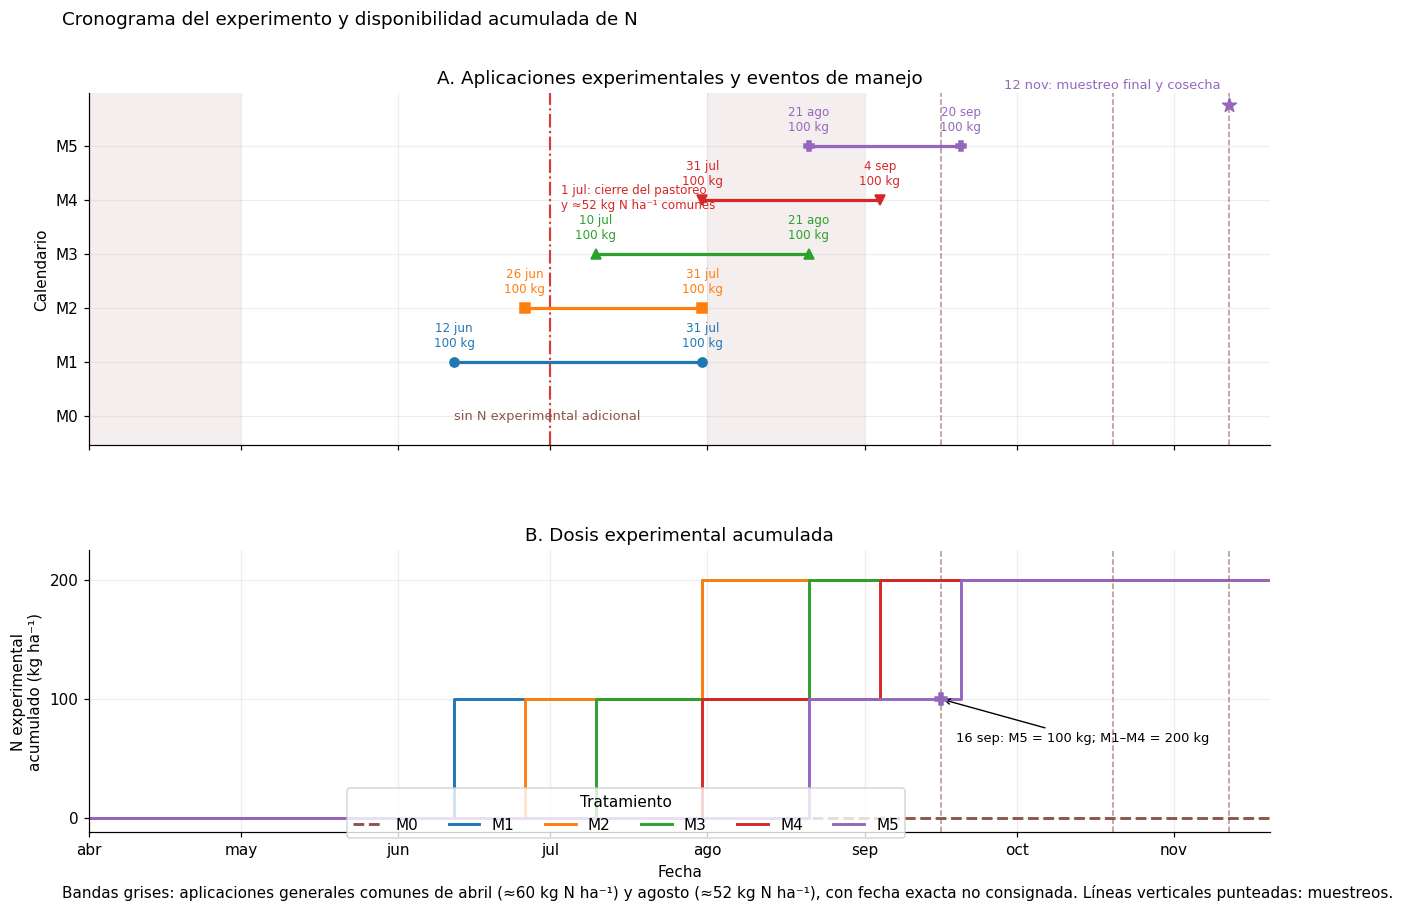

In [5]:
display_output(data.schedule)


def plot_schedule_and_cumulative_n() -> None:
    study_start = pd.Timestamp("2025-04-01")
    study_end = pd.Timestamp("2025-11-20")
    grazing_closure = pd.Timestamp("2025-07-01")
    common_n_periods = [
        (
            pd.Timestamp("2025-04-01"),
            pd.Timestamp("2025-05-01"),
            "≈60 kg N ha⁻¹ comunes\n(fecha de abril no precisada)",
        ),
        (
            pd.Timestamp("2025-08-01"),
            pd.Timestamp("2025-09-01"),
            "≈52 kg N ha⁻¹ comunes\n(fecha de agosto no precisada)",
        ),
    ]

    fig, axes = mpl.subplots(
        2,
        1,
        figsize=(12.2, 8.3),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0]},
    )
    calendar_ax, cumulative_ax = np.asarray(axes).ravel()

    # Panel A: calendario completo.
    treatment_positions = {
        treatment: index for index, treatment in enumerate(TREATMENTS)
    }
    for start, end, _label in common_n_periods:
        calendar_ax.axvspan(
            start,
            end,
            color=PLOT_PALETTE[5],
            alpha=0.09,
            linewidth=0,
        )

    calendar_ax.axvline(
        grazing_closure,
        color=PLOT_PALETTE[3],
        linestyle="-.",
        linewidth=1.4,
        alpha=0.9,
    )
    calendar_ax.annotate(
        "1 jul: cierre del pastoreo\ny ≈52 kg N ha⁻¹ comunes",
        xy=(grazing_closure, 4.35),
        xytext=(7, -2),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=7.8,
        color=PLOT_PALETTE[3],
    )

    for sample_date in DATES:
        calendar_ax.axvline(
            sample_date,
            color=PLOT_PALETTE[5],
            linestyle="--",
            linewidth=1,
            alpha=0.65,
        )

    for treatment in TREATMENTS:
        y = treatment_positions[treatment]
        row = data.schedule.loc[data.schedule["treatment"].eq(treatment)].iloc[0]
        if treatment == "M0":
            calendar_ax.text(
                pd.Timestamp("2025-06-12"),
                y,
                "sin N experimental adicional",
                va="center",
                ha="left",
                fontsize=8.5,
                color=PLOT_PALETTE[5],
            )
            continue

        dates = [row["first_application"], row["second_application"]]
        calendar_ax.plot(
            dates,
            [y, y],
            color=TREATMENT_COLORS[treatment],
            marker=TREATMENT_MARKERS[treatment],
            linewidth=2.1,
            markersize=6,
            label=treatment,
        )
        for application_date in dates:
            application_month = {6: "jun", 7: "jul", 8: "ago", 9: "sep"}[
                application_date.month
            ]
            calendar_ax.annotate(
                f"{application_date.day} {application_month}" "\n100 kg",
                xy=(application_date, y),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=7.8,
                color=TREATMENT_COLORS[treatment],
            )

    calendar_ax.scatter(
        [DATES[-1]],
        [len(TREATMENTS) - 0.25],
        marker="*",
        s=90,
        color=PLOT_PALETTE[4],
        zorder=5,
    )
    calendar_ax.annotate(
        "12 nov: muestreo final y cosecha",
        xy=(DATES[-1], len(TREATMENTS) - 0.25),
        xytext=(-6, 9),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=8.5,
        color=PLOT_PALETTE[4],
    )
    calendar_ax.set_yticks(
        list(treatment_positions.values()),
        list(treatment_positions.keys()),
    )
    calendar_ax.set_ylabel("Calendario")
    calendar_ax.set_title("A. Aplicaciones experimentales y eventos de manejo")
    calendar_ax.set_ylim(-0.55, len(TREATMENTS) - 0.02)

    # Panel B: dosis experimental acumulada.
    for treatment in TREATMENTS:
        row = data.schedule.loc[data.schedule["treatment"].eq(treatment)].iloc[0]
        if treatment == "M0":
            x_values = [study_start, study_end]
            y_values = [0.0, 0.0]
        else:
            x_values = [
                study_start,
                row["first_application"],
                row["second_application"],
                study_end,
            ]
            y_values = [0.0, 100.0, 200.0, 200.0]
        cumulative_ax.step(
            x_values,
            y_values,
            where="post",
            color=TREATMENT_COLORS[treatment],
            linestyle="--" if treatment == "M0" else "-",
            linewidth=1.9,
            label=treatment,
        )

    for sample_date in DATES:
        cumulative_ax.axvline(
            sample_date,
            color=PLOT_PALETTE[5],
            linestyle="--",
            linewidth=1,
            alpha=0.65,
        )

    cumulative_ax.scatter(
        [DATES[0]],
        [100],
        color=TREATMENT_COLORS["M5"],
        marker=TREATMENT_MARKERS["M5"],
        s=55,
        zorder=5,
    )
    cumulative_ax.annotate(
        "16 sep: M5 = 100 kg; M1–M4 = 200 kg",
        xy=(DATES[0], 100),
        xytext=(10, -28),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->", "linewidth": 0.9},
        fontsize=8.5,
        ha="left",
    )
    cumulative_ax.set_yticks([0, 100, 200])
    cumulative_ax.set_ylim(-12, 225)
    cumulative_ax.set_ylabel("N experimental\nacumulado (kg ha⁻¹)")
    cumulative_ax.set_title("B. Dosis experimental acumulada")
    cumulative_ax.set_xlabel("Fecha")

    month_ticks = pd.date_range("2025-04-01", "2025-11-01", freq="MS")
    month_labels = ["abr", "may", "jun", "jul", "ago", "sep", "oct", "nov"]
    cumulative_ax.set_xticks(month_ticks, month_labels)
    cumulative_ax.set_xlim(study_start, study_end)

    handles, labels = cumulative_ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Tratamiento",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.075),
        ncol=6,
    )
    fig.suptitle(
        "Cronograma del experimento y disponibilidad acumulada de N",
        x=0.08,
        y=0.99,
        ha="left",
    )
    fig.text(
        0.08,
        0.018,
        (
            "Bandas grises: aplicaciones generales comunes de abril (≈60 kg N ha⁻¹) y agosto "
            "(≈52 kg N ha⁻¹), con fecha exacta no consignada. Líneas verticales punteadas: muestreos."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        bottom=0.09,
        top=0.90,
        hspace=0.33,
    )
    save_figure(fig, "figura_01_cronograma_y_n_acumulado")
    mpl.show()
    mpl.close(fig)


plot_schedule_and_cumulative_n()

### 2.4 Precipitación y riego suplementario durante el experimento

Los valores se transcriben de la tabla de caracterización hídrica de la tesis. La figura muestra **entradas brutas de agua**: precipitación común a ambos sectores y riego suplementario agregado al sector regado. No representa agua almacenada, disponible ni consumida por el cultivo; por eso no convierte la diferencia entre sectores en una estimación causal del efecto del riego.

,month,precipitation_mm,supplemental_irrigation_mm,irrigated_total_mm
0,Jun,43,15,58
1,Jul,62,0,62
2,Ago,101,0,101
3,Sep,89,30,119
4,Oct,141,90,231
5,Nov,74,30,104


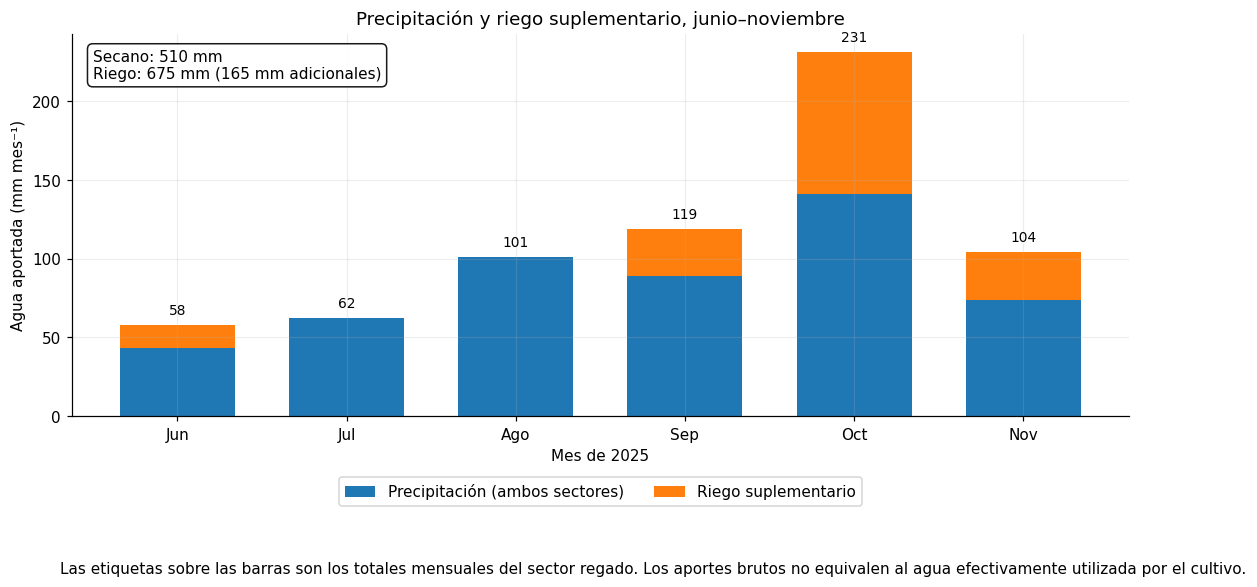

In [6]:
water_inputs = pd.DataFrame(
    {
        "month": ["Jun", "Jul", "Ago", "Sep", "Oct", "Nov"],
        "precipitation_mm": [43, 62, 101, 89, 141, 74],
        "supplemental_irrigation_mm": [15, 0, 0, 30, 90, 30],
    }
)
water_inputs["irrigated_total_mm"] = (
    water_inputs["precipitation_mm"] + water_inputs["supplemental_irrigation_mm"]
)
assert water_inputs["precipitation_mm"].sum() == 510
assert water_inputs["supplemental_irrigation_mm"].sum() == 165
assert water_inputs["irrigated_total_mm"].sum() == 675
display_output(water_inputs)

positions = np.arange(len(water_inputs), dtype=float)
fig, ax = mpl.subplots(figsize=(10.8, 5.7))
ax.bar(
    positions,
    water_inputs["precipitation_mm"],
    width=0.68,
    color=PLOT_PALETTE[0],
    label="Precipitación (ambos sectores)",
)
ax.bar(
    positions,
    water_inputs["supplemental_irrigation_mm"],
    width=0.68,
    bottom=water_inputs["precipitation_mm"],
    color=PLOT_PALETTE[1],
    label="Riego suplementario",
)
for position, total in zip(
    positions,
    water_inputs["irrigated_total_mm"],
    strict=True,
):
    ax.text(
        position,
        total + 5,
        f"{total:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.text(
    0.02,
    0.96,
    "Secano: 510 mm\nRiego: 675 mm (165 mm adicionales)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": mpl.rcParams["axes.edgecolor"],
        "alpha": 0.90,
    },
)
ax.set_xticks(positions, water_inputs["month"])
ax.set_ylabel("Agua aportada (mm mes⁻¹)")
ax.set_xlabel("Mes de 2025")
ax.set_title("Precipitación y riego suplementario, junio–noviembre")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
)
fig.text(
    0.08,
    0.02,
    (
        "Las etiquetas sobre las barras son los totales mensuales del sector regado. "
        "Los aportes brutos no equivalen al agua efectivamente utilizada por el cultivo."
    ),
    color=mpl.rcParams["axes.labelcolor"],
)
fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.27,
    top=0.88,
)
save_figure(fig, "figura_02_aportes_mensuales_de_agua")
mpl.show()
mpl.close(fig)

## 3. Funciones para reproducir el análisis de bloques completos al azar

Para cada sector se ajusta:

$$
Y_{ij}=\mu+T_i+B_j+\varepsilon_{ij}.
$$

Se usa ANOVA tipo II, que reproduce los valores de p de la tesis. Las medias marginales se promedian sobre los cuatro bloques. Cuando el efecto global del tratamiento es significativo, las comparaciones de Tukey se calculan sobre diferencias entre medias marginales ajustadas.

In [7]:
@dataclass
class RCBDResult:
    outcome: str
    treatments: tuple[str, ...]
    frame: pd.DataFrame
    fit: Any
    anova: pd.DataFrame
    means: pd.DataFrame
    pairwise: pd.DataFrame
    cv_pct: float


def scalar_psturng_fn(q_value: float, groups: int, df: float) -> float:
    value = psturng_fn(q_value, groups, df)
    return float(np.asarray(value).reshape(-1)[0])


def maximal_nonsignificant_cliques(
    levels: Sequence[str],
    nonsignificant: dict[tuple[str, str], bool],
) -> list[set[str]]:
    nodes = list(levels)
    cliques: list[set[str]] = []
    for size in range(1, len(nodes) + 1):
        for subset_tuple in combinations(nodes, size):
            subset = set(subset_tuple)
            if all(
                nonsignificant.get((a, b) if a <= b else (b, a), False)
                for a, b in combinations(subset, 2)
            ):
                cliques.append(subset)
    maximal = [
        clique for clique in cliques if not any(clique < other for other in cliques)
    ]
    # Eliminar duplicados preservando contenido.
    unique: list[set[str]] = []
    for clique in maximal:
        if clique not in unique:
            unique.append(clique)
    return unique


def compact_letters(
    means: pd.DataFrame,
    pairwise: pd.DataFrame,
    *,
    alpha: float = ALPHA,
) -> dict[str, str]:
    ordered = means.sort_values("estimate", ascending=False)["treatment"].tolist()
    nonsig: dict[tuple[str, str], bool] = {}
    for raw_row in pairwise.itertuples(index=False):
        row = cast(Any, raw_row)
        nonsig[tuple(sorted((row.group1, row.group2)))] = row.p_tukey >= alpha
    cliques = maximal_nonsignificant_cliques(ordered, nonsig)
    cliques.sort(
        key=lambda clique: max(
            means.set_index("treatment").loc[list(clique), "estimate"]
        ),
        reverse=True,
    )
    alphabet = list("abcdefghijklmnopqrstuvwxyz")
    if len(cliques) > len(alphabet):
        raise RuntimeError("Demasiadas clases para el alfabeto compacto")
    letters = {level: "" for level in ordered}
    for letter, clique in zip(alphabet, cliques):
        for level in clique:
            letters[level] += letter
    return letters


def adjusted_treatment_means(
    fit: Any,
    treatments: Sequence[str],
    blocks: Sequence[str] = BLOCKS,
) -> tuple[pd.DataFrame, dict[str, np.ndarray], np.ndarray]:
    beta = fit.params.to_numpy()
    covariance = fit.cov_params().to_numpy()
    design_info = fit.model.data.design_info

    vectors: dict[str, np.ndarray] = {}
    rows: list[dict[str, object]] = []
    for treatment in treatments:
        new = pd.DataFrame(
            {
                "treatment": [treatment] * len(blocks),
                "block": list(blocks),
            }
        )
        new["treatment"] = categorical(new["treatment"], treatments)
        new["block"] = categorical(new["block"], blocks)
        design = np.asarray(patsy_api.build_design_matrices([design_info], new)[0])
        xbar = design.mean(axis=0)
        estimate = float(xbar @ beta)
        se = float(np.sqrt(xbar @ covariance @ xbar))
        vectors[treatment] = xbar
        rows.append(
            {
                "treatment": treatment,
                "estimate": estimate,
                "se": se,
                "ci_low": estimate - stats.t.ppf(0.975, fit.df_resid) * se,
                "ci_high": estimate + stats.t.ppf(0.975, fit.df_resid) * se,
            }
        )
    return pd.DataFrame(rows), vectors, covariance


def fit_rcbd(
    frame: pd.DataFrame,
    *,
    outcome: str,
    treatments: Sequence[str],
) -> RCBDResult:
    subset = frame.loc[frame["treatment"].astype(str).isin(treatments)].copy()
    subset = subset.dropna(subset=[outcome, "block", "treatment"])
    subset["treatment"] = categorical(subset["treatment"], treatments)
    subset["block"] = categorical(subset["block"], BLOCKS)

    fit = smf_api.ols(f"{outcome} ~ C(treatment) + C(block)", data=subset).fit()
    anova = sm_api.stats.anova_lm(fit, typ=2)
    means, vectors, covariance = adjusted_treatment_means(fit, treatments=treatments)

    pairs: list[dict[str, object]] = []
    k = len(treatments)
    q_critical = float(qsturng_fn(1.0 - ALPHA, k, fit.df_resid))
    for group1, group2 in combinations(treatments, 2):
        contrast = vectors[group1] - vectors[group2]
        difference = float(contrast @ fit.params.to_numpy())
        se_difference = float(np.sqrt(contrast @ covariance @ contrast))
        q_stat = math.sqrt(2.0) * abs(difference) / se_difference
        p_tukey = scalar_psturng_fn(q_stat, k, fit.df_resid)
        half_width = q_critical * se_difference / math.sqrt(2.0)
        pairs.append(
            {
                "group1": group1,
                "group2": group2,
                "difference": difference,
                "se": se_difference,
                "ci_low": difference - half_width,
                "ci_high": difference + half_width,
                "p_tukey": p_tukey,
                "reject": p_tukey < ALPHA,
            }
        )
    pairwise = pd.DataFrame(pairs)
    global_p = float(anova.loc["C(treatment)", "PR(>F)"])
    if global_p < ALPHA:
        letters = compact_letters(means, pairwise)
        means["tukey_group"] = means["treatment"].map(letters)
    else:
        means["tukey_group"] = "—"
    means["n"] = means["treatment"].map(
        subset.groupby("treatment", observed=True)[outcome].count()
    )

    mse = float(anova.loc["Residual", "sum_sq"] / anova.loc["Residual", "df"])
    cv_pct = 100.0 * math.sqrt(mse) / float(cast(Any, subset[outcome].mean()))
    return RCBDResult(
        outcome=outcome,
        treatments=tuple(treatments),
        frame=subset,
        fit=fit,
        anova=anova,
        means=means,
        pairwise=pairwise,
        cv_pct=cv_pct,
    )


def rcbd_result_row(
    result: RCBDResult,
    *,
    sector: str,
    date: pd.Timestamp | None,
    comparison: str,
) -> dict[str, object]:
    return {
        "outcome": result.outcome,
        "label": OUTCOME_LABELS.get(result.outcome, result.outcome),
        "sector": sector,
        "date": date,
        "comparison": comparison,
        "n": len(result.frame),
        "p_treatment": float(cast(Any, result.anova.loc["C(treatment)", "PR(>F)"])),
        "p_block": float(cast(Any, result.anova.loc["C(block)", "PR(>F)"])),
        "cv_pct": result.cv_pct,
    }

## 4. Reproducción de los ANOVA por fecha y sector

La tesis analiza biomasa, concentración de N, N acumulado e INN por separado en cada fecha y sector. Se ejecutan las dos comparaciones predefinidas:

- **principal:** M1–M5;
- **complementaria:** M0–M5.

In [8]:
LONGITUDINAL_OUTCOMES = [
    "biomass_kg_ha_used",
    "n_pct",
    "q_kg_n_ha",
    "nni_revised",
]

longitudinal_rcbd_rows: list[dict[str, object]] = []
longitudinal_rcbd_models: dict[tuple[str, pd.Timestamp, str, str], RCBDResult] = {}

for outcome in LONGITUDINAL_OUTCOMES:
    for date in DATES:
        for sector in SECTORS:
            frame = data.longitudinal.loc[
                data.longitudinal["date"].astype("datetime64[ns]").eq(date)
                & data.longitudinal["sector"].astype(str).eq(sector)
            ].copy()
            for treatments, comparison in [
                (FERTILIZED, "M1–M5"),
                (TREATMENTS, "M0–M5"),
            ]:
                result = fit_rcbd(
                    frame,
                    outcome=outcome,
                    treatments=treatments,
                )
                key = (outcome, date, sector, comparison)
                longitudinal_rcbd_models[key] = result
                longitudinal_rcbd_rows.append(
                    rcbd_result_row(
                        result,
                        sector=sector,
                        date=date,
                        comparison=comparison,
                    )
                )

longitudinal_rcbd = pd.DataFrame(longitudinal_rcbd_rows)
longitudinal_rcbd["date_label"] = longitudinal_rcbd["date"].map(DATE_LABELS)

display_output(
    longitudinal_rcbd[
        [
            "label",
            "date_label",
            "sector",
            "comparison",
            "n",
            "p_treatment",
            "p_block",
            "cv_pct",
        ]
    ].round(4)
)

,label,date_label,sector,comparison,n,p_treatment,p_block,cv_pct
0,Biomasa aérea (kg MS ha⁻¹),16 sep,Secano,M1–M5,20,0.0015,0.2129,25.5682
1,Biomasa aérea (kg MS ha⁻¹),16 sep,Secano,M0–M5,24,0.0005,0.3271,26.3405
2,Biomasa aérea (kg MS ha⁻¹),16 sep,Riego,M1–M5,20,0.0333,0.5347,14.8866
3,Biomasa aérea (kg MS ha⁻¹),16 sep,Riego,M0–M5,24,0.0015,0.6293,14.8339
4,Biomasa aérea (kg MS ha⁻¹),20 oct,Secano,M1–M5,20,0.1725,0.1969,16.6509
5,Biomasa aérea (kg MS ha⁻¹),20 oct,Secano,M0–M5,24,0.0008,0.0827,16.3003
6,Biomasa aérea (kg MS ha⁻¹),20 oct,Riego,M1–M5,20,0.2021,0.4075,15.4058
7,Biomasa aérea (kg MS ha⁻¹),20 oct,Riego,M0–M5,24,0.0002,0.3449,15.3022
8,Biomasa aérea (kg MS ha⁻¹),12 nov,Secano,M1–M5,20,0.1017,0.3180,13.5580
9,Biomasa aérea (kg MS ha⁻¹),12 nov,Secano,M0–M5,24,0.0290,0.4069,16.2499


### 4.1 Validaciones contra resultados publicados

Estas aserciones convierten algunos resultados centrales en pruebas de regresión del cuaderno.

In [9]:
def assert_close(actual: float, expected: float, tolerance: float = 5e-4) -> None:
    if not np.isclose(actual, expected, atol=tolerance, rtol=0):
        raise AssertionError(f"{actual=} no reproduce {expected=}")


validation_targets = [
    ("n_pct", pd.Timestamp("2025-09-16"), "Secano", "M1–M5", 0.2518),
    ("n_pct", pd.Timestamp("2025-10-20"), "Riego", "M1–M5", 0.0001),
    ("q_kg_n_ha", pd.Timestamp("2025-09-16"), "Secano", "M1–M5", 0.0061),
    ("q_kg_n_ha", pd.Timestamp("2025-11-12"), "Riego", "M1–M5", 0.1037),
]
for outcome, date, sector, comparison, expected in validation_targets:
    actual = longitudinal_rcbd.loc[
        longitudinal_rcbd["outcome"].eq(outcome)
        & longitudinal_rcbd["date"].eq(date)
        & longitudinal_rcbd["sector"].eq(sector)
        & longitudinal_rcbd["comparison"].eq(comparison),
        "p_treatment",
    ].iloc[0]
    assert_close(actual, expected)

print("Las validaciones longitudinales seleccionadas reproducen la tesis.")

Las validaciones longitudinales seleccionadas reproducen la tesis.


### 4.2 Trayectorias descriptivas con incertidumbre

Los puntos son medias sin ajustar y las barras representan intervalos t de 95 %. La inferencia de la tesis sigue siendo el ANOVA de bloques; estas figuras muestran magnitud y precisión, no solo significancia.

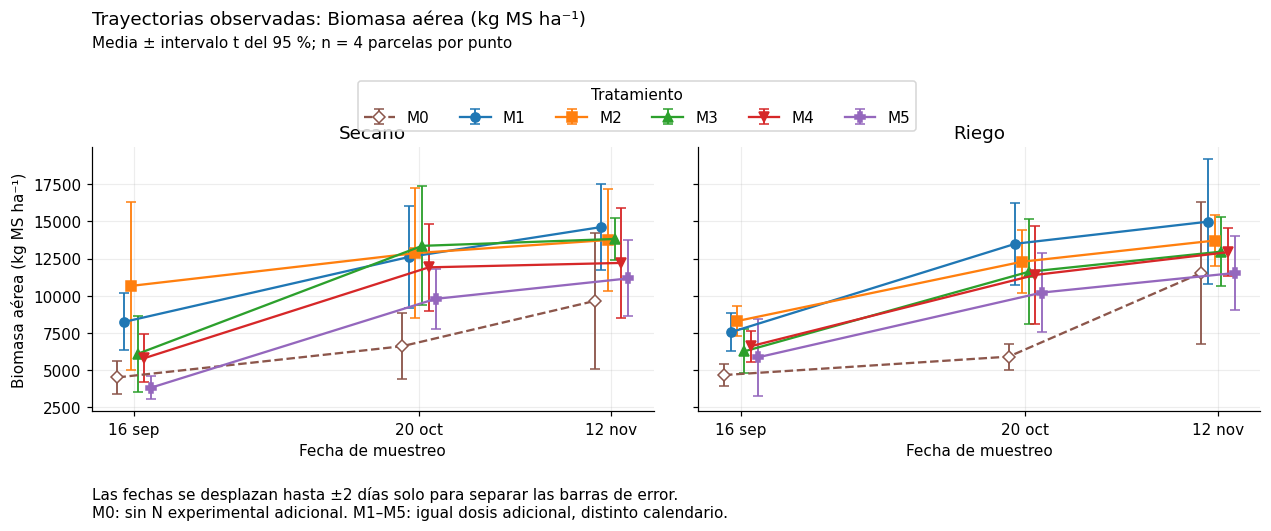

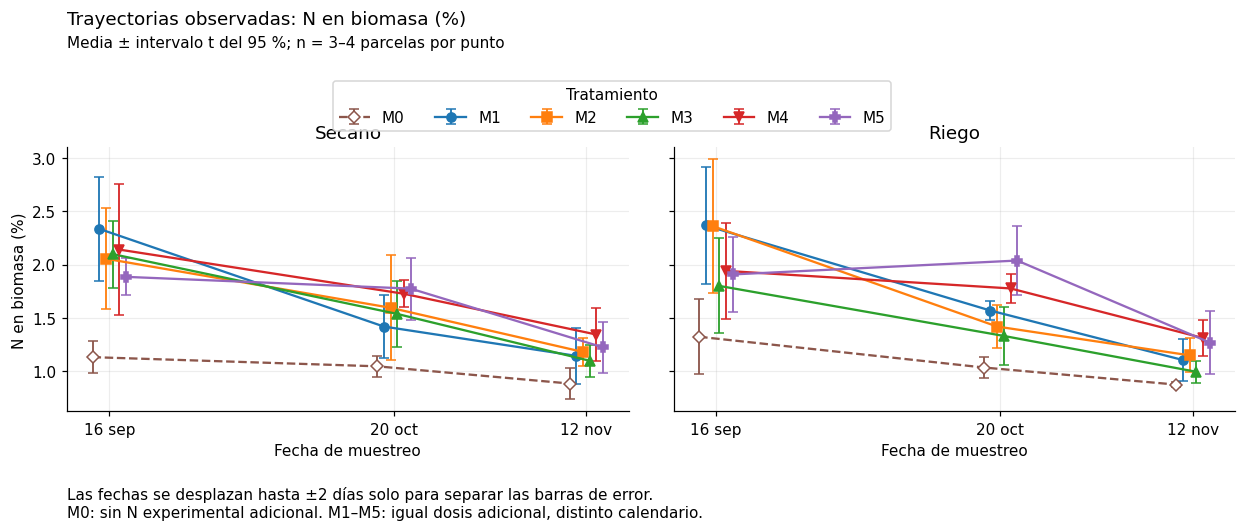

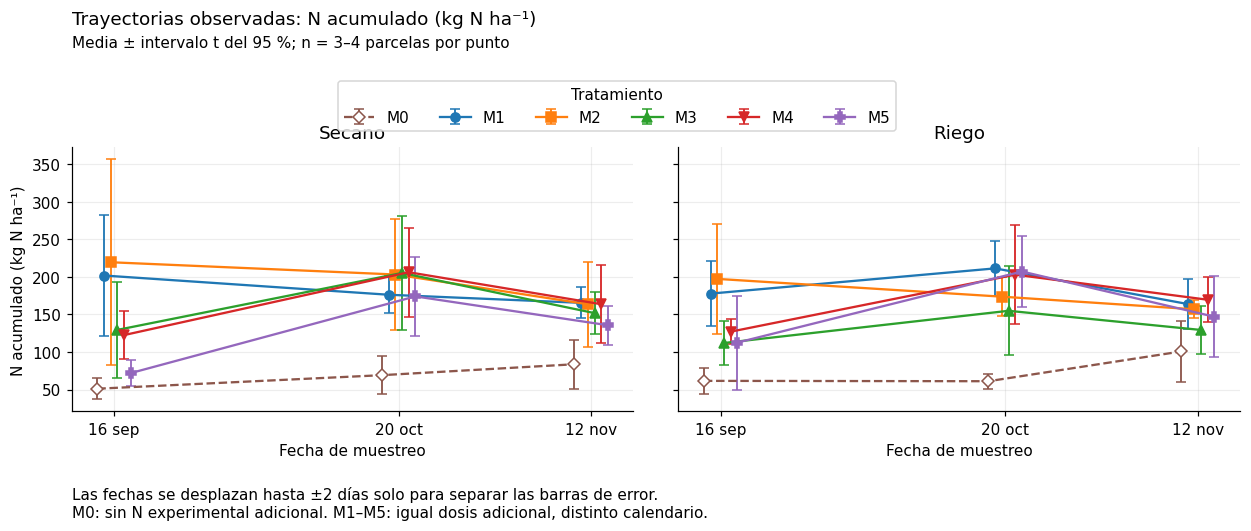

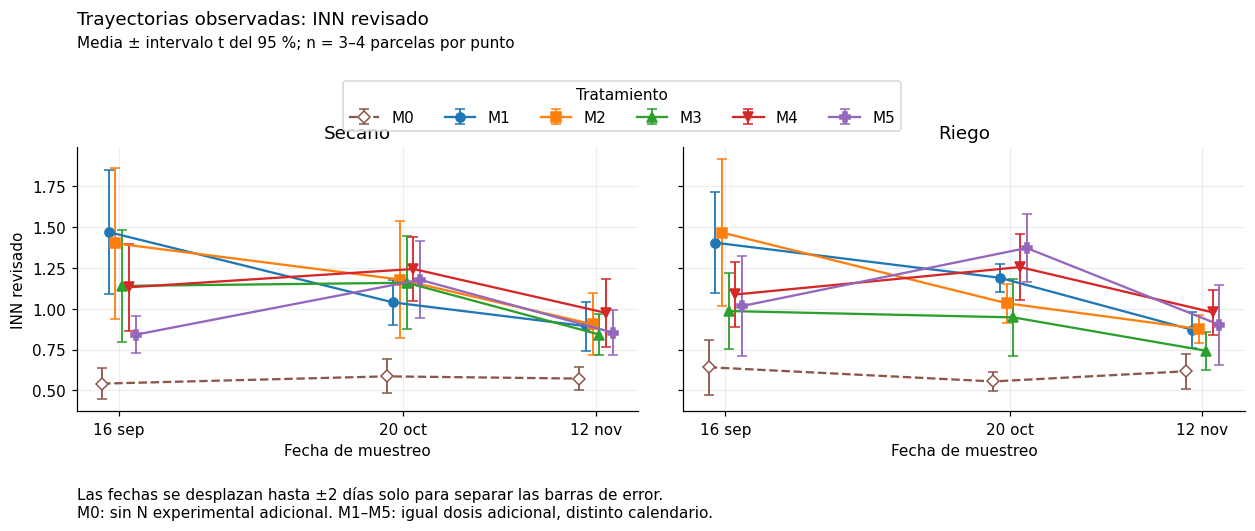

In [10]:
def treatment_trajectory_plot(
    frame: pd.DataFrame,
    *,
    outcome: str,
    treatments: Sequence[str] = TREATMENTS,
    filename_stem: str | None = None,
) -> None:
    subset = (
        frame.loc[frame["treatment"].astype(str).isin(treatments)]
        .dropna(subset=[outcome])
        .copy()
    )
    summary = (
        subset.groupby(["sector", "treatment", "date"], observed=True)[outcome]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary["se"] = summary["std"] / np.sqrt(summary["count"])
    degrees_freedom = np.maximum(summary["count"].to_numpy(dtype=int) - 1, 1)
    summary["half_width"] = stats.t.ppf(0.975, degrees_freedom) * summary["se"]
    minimum_n = int(summary["count"].min())
    maximum_n = int(summary["count"].max())
    sample_size_text = (
        f"n = {minimum_n} parcelas por punto"
        if minimum_n == maximum_n
        else f"n = {minimum_n}–{maximum_n} parcelas por punto"
    )
    date_offsets = {
        treatment: pd.Timedelta(days=float(offset_days))
        for treatment, offset_days in zip(
            treatments,
            np.linspace(-2.0, 2.0, len(treatments)),
            strict=True,
        )
    }

    fig, axes = mpl.subplots(1, 2, figsize=(11.8, 4.8), sharex=True, sharey=True)
    axes_array = np.asarray(axes).ravel()
    for panel_index, sector in enumerate(SECTORS):
        ax = axes_array[panel_index]
        sector_summary = summary.loc[summary["sector"].astype(str).eq(sector)]
        for treatment in treatments:
            treatment_summary = sector_summary.loc[
                sector_summary["treatment"].astype(str).eq(treatment)
            ].sort_values("date")
            plot_dates = (
                pd.DatetimeIndex(treatment_summary["date"]) + date_offsets[treatment]
            )
            ax.errorbar(
                plot_dates,
                treatment_summary["mean"],
                yerr=treatment_summary["half_width"],
                color=TREATMENT_COLORS[treatment],
                linestyle="--" if treatment == "M0" else "-",
                marker=TREATMENT_MARKERS[treatment],
                markerfacecolor=(
                    "white" if treatment == "M0" else TREATMENT_COLORS[treatment]
                ),
                markeredgecolor=TREATMENT_COLORS[treatment],
                capsize=3,
                elinewidth=1.2,
                label=treatment,
                zorder=3,
            )
        ax.set_title(sector)
        ax.set_xticks(DATES, [DATE_LABELS[date] for date in DATES])
        ax.set_xlabel("Fecha de muestreo")
        if panel_index == 0:
            ax.set_ylabel(OUTCOME_LABELS[outcome])

    handles, labels = axes_array[0].get_legend_handles_labels()
    fig.suptitle(
        f"Trayectorias observadas: {OUTCOME_LABELS[outcome]}", x=0.08, y=0.98, ha="left"
    )
    fig.text(
        0.08,
        0.91,
        f"Media ± intervalo t del 95 %; {sample_size_text}",
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.legend(
        handles,
        labels,
        title="Tratamiento",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.86),
        ncol=len(treatments),
    )
    fig.text(
        0.08,
        0.02,
        (
            "Las fechas se desplazan hasta ±2 días solo para separar las barras de error.\n"
            "M0: sin N experimental adicional. M1–M5: igual dosis adicional, distinto calendario."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.22, top=0.72, wspace=0.08)
    if filename_stem is not None:
        save_figure(fig, filename_stem)
    mpl.show()
    mpl.close(fig)


for outcome in LONGITUDINAL_OUTCOMES:
    treatment_trajectory_plot(
        data.longitudinal,
        outcome=outcome,
        filename_stem=f"anexo_trayectorias_observadas_{outcome}",
    )

## 5. Variables de cosecha y componentes del rendimiento

Las variables se reconstruyen con las mismas identidades de la tesis. El número de semillas por panoja es **estimado**, no contado de forma independiente.

In [11]:
FINAL_OUTCOMES = [
    "panicle_density_m2",
    "estimated_seeds_per_panicle",
    "w1000_g",
    "clean_yield_kg_ha",
    "harvest_index_pct",
    "cleaning_loss_pct",
]

final_rcbd_rows: list[dict[str, object]] = []
final_rcbd_models: dict[tuple[str, str, str], RCBDResult] = {}
for outcome in FINAL_OUTCOMES:
    for sector in SECTORS:
        frame = data.harvest.loc[data.harvest["sector"].astype(str).eq(sector)].copy()
        for treatments, comparison in [
            (FERTILIZED, "M1–M5"),
            (TREATMENTS, "M0–M5"),
        ]:
            result = fit_rcbd(
                frame,
                outcome=outcome,
                treatments=treatments,
            )
            final_rcbd_models[(outcome, sector, comparison)] = result
            final_rcbd_rows.append(
                rcbd_result_row(
                    result,
                    sector=sector,
                    date=None,
                    comparison=comparison,
                )
            )

# Indicadores que reproducen el patrón del rendimiento.
for outcome, treatment_sets in [
    ("agronomic_efficiency", [(FERTILIZED, "M1–M5")]),
    (
        "apparent_water_productivity",
        [(FERTILIZED, "M1–M5"), (TREATMENTS, "M0–M5")],
    ),
    (
        "dirty_yield_kg_ha",
        [(FERTILIZED, "M1–M5"), (TREATMENTS, "M0–M5")],
    ),
]:
    for sector in SECTORS:
        frame = data.harvest.loc[data.harvest["sector"].astype(str).eq(sector)].copy()
        for treatments, comparison in treatment_sets:
            result = fit_rcbd(frame, outcome=outcome, treatments=treatments)
            final_rcbd_models[(outcome, sector, comparison)] = result
            final_rcbd_rows.append(
                rcbd_result_row(
                    result,
                    sector=sector,
                    date=None,
                    comparison=comparison,
                )
            )

final_rcbd = pd.DataFrame(final_rcbd_rows)
display_output(
    final_rcbd[
        ["label", "sector", "comparison", "n", "p_treatment", "p_block", "cv_pct"]
    ].round(4)
)

,label,sector,comparison,n,p_treatment,p_block,cv_pct
0,Panojas m⁻²,Secano,M1–M5,20,0.0945,0.5211,13.1158
1,Panojas m⁻²,Secano,M0–M5,24,0.0164,0.3685,12.4050
2,Panojas m⁻²,Riego,M1–M5,20,0.0053,0.9889,13.1077
3,Panojas m⁻²,Riego,M0–M5,24,0.0085,0.7112,14.7073
4,Semillas estimadas por panoja,Secano,M1–M5,20,0.1496,0.5610,12.2884
5,Semillas estimadas por panoja,Secano,M0–M5,24,0.0007,0.1845,13.1817
6,Semillas estimadas por panoja,Riego,M1–M5,20,0.0088,0.4843,10.9024
7,Semillas estimadas por panoja,Riego,M0–M5,24,0.0001,0.7987,12.4335
8,Peso de mil semillas (g),Secano,M1–M5,20,0.5159,0.6123,6.5715
9,Peso de mil semillas (g),Secano,M0–M5,24,0.5728,0.5221,6.1953


### 5.1 Reproducción exacta del resultado central de rendimiento

In [12]:
yield_rows = final_rcbd.loc[final_rcbd["outcome"].eq("clean_yield_kg_ha")].copy()
display_output(yield_rows[["sector", "comparison", "p_treatment", "cv_pct"]].round(6))

secano_primary = yield_rows.loc[
    yield_rows["sector"].eq("Secano") & yield_rows["comparison"].eq("M1–M5"),
    "p_treatment",
].iloc[0]
riego_primary = yield_rows.loc[
    yield_rows["sector"].eq("Riego") & yield_rows["comparison"].eq("M1–M5"),
    "p_treatment",
].iloc[0]
assert_close(secano_primary, 0.4287)
assert_close(riego_primary, 0.1759)
secano_all_cv = yield_rows.loc[
    yield_rows["sector"].eq("Secano") & yield_rows["comparison"].eq("M0–M5"),
    "cv_pct",
].iloc[0]
riego_all_cv = yield_rows.loc[
    yield_rows["sector"].eq("Riego") & yield_rows["comparison"].eq("M0–M5"),
    "cv_pct",
].iloc[0]
assert_close(secano_all_cv, 12.1, tolerance=0.02)
assert_close(riego_all_cv, 13.5, tolerance=0.02)
print("Los CV publicados (12.1 % y 13.5 %) corresponden al análisis M0–M5.")

for sector in SECTORS:
    result = final_rcbd_models[("clean_yield_kg_ha", sector, "M0–M5")]
    display_output(Markdown(f"**{sector}: medias ajustadas y grupos de Tukey, M0–M5**"))
    display_output(result.means.round(2))

,sector,comparison,p_treatment,cv_pct
12,Secano,M1–M5,0.4287,10.1926
13,Secano,M0–M5,0.0000,12.0998
14,Riego,M1–M5,0.1759,12.8795
15,Riego,M0–M5,0.0001,13.4978


Los CV publicados (12.1 % y 13.5 %) corresponden al análisis M0–M5.


**Secano: medias ajustadas y grupos de Tukey, M0–M5**

,treatment,estimate,se,ci_low,ci_high,tukey_group,n
0,M0,702.6300,75.9400,540.7600,864.5000,b,4
1,M1,"1,374.0100",75.9400,"1,212.1500","1,535.8800",a,4
2,M2,"1,367.1100",75.9400,"1,205.2400","1,528.9700",a,4
3,M3,"1,343.4200",75.9400,"1,181.5500","1,505.2900",a,4
4,M4,"1,470.7200",75.9400,"1,308.8600","1,632.5900",a,4
5,M5,"1,273.6800",75.9400,"1,111.8200","1,435.5500",a,4


**Riego: medias ajustadas y grupos de Tukey, M0–M5**

,treatment,estimate,se,ci_low,ci_high,tukey_group,n
0,M0,645.3900,79.5700,475.8000,814.9900,b,4
1,M1,"1,243.0900",79.5700,"1,073.5000","1,412.6800",a,4
2,M2,"1,452.3000",79.5700,"1,282.7100","1,621.8900",a,4
3,M3,"1,241.7800",79.5700,"1,072.1900","1,411.3700",a,4
4,M4,"1,338.4900",79.5700,"1,168.9000","1,508.0800",a,4
5,M5,"1,152.6300",79.5700,983.0400,"1,322.2200",a,4


### 5.2 Rendimiento limpio: separar la respuesta al N de la comparación entre calendarios

La fila superior muestra M0–M5 y hace visible la respuesta marginal al N experimental adicional. La fila inferior restringe la escala a M1–M5, que es la pregunta central sobre calendarios. Los puntos son parcelas individuales; los diamantes y barras son medias ajustadas por bloque e intervalos puntuales del 95 % del modelo de bloques completos al azar.

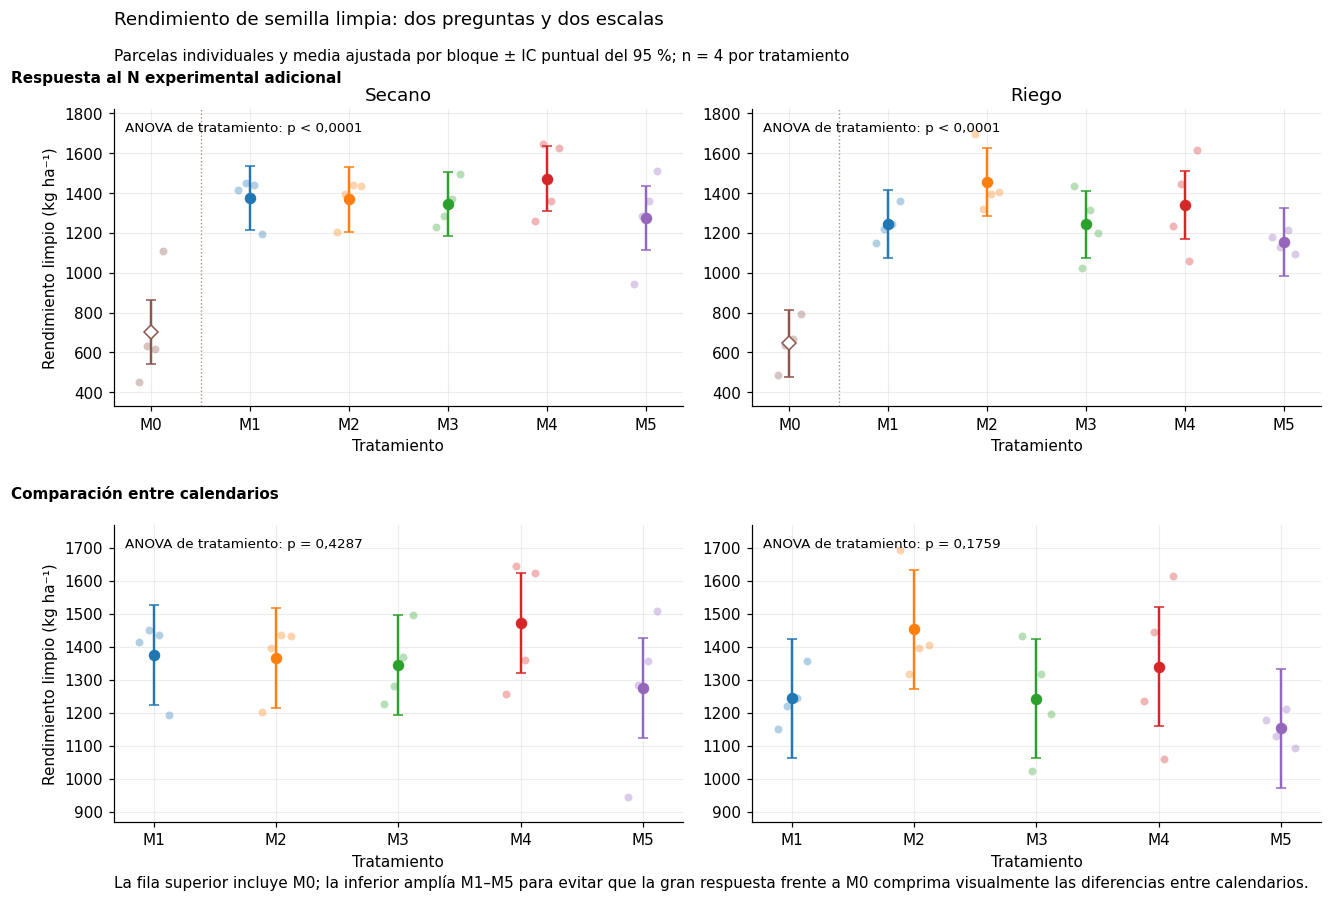

In [13]:
def yield_row_limits(
    frame: pd.DataFrame,
    row_specs: Sequence[tuple[Sequence[str], str, str]],
) -> list[tuple[float, float]]:
    limits: list[tuple[float, float]] = []
    for treatments, comparison, _ in row_specs:
        raw_values = frame.loc[
            frame["treatment"].astype(str).isin(treatments),
            "clean_yield_kg_ha",
        ].dropna()
        model_limits: list[float] = []
        for sector in SECTORS:
            result = final_rcbd_models[("clean_yield_kg_ha", sector, comparison)]
            model_limits.extend(result.means["ci_low"].tolist())
            model_limits.extend(result.means["ci_high"].tolist())
        lower = min(float(raw_values.min()), min(model_limits))
        upper = max(float(raw_values.max()), max(model_limits))
        padding = 0.10 * (upper - lower)
        limits.append((max(0.0, lower - padding), upper + padding))
    return limits


def plot_yield_treatment_points(
    ax: Any,
    *,
    positions: np.ndarray,
    treatments: Sequence[str],
    sector_data: pd.DataFrame,
    means: pd.DataFrame,
    block_offsets: dict[str, float],
) -> None:
    for position, treatment in zip(positions, treatments, strict=True):
        observations = sector_data.loc[
            sector_data["treatment"].astype(str).eq(treatment)
        ].sort_values("block")
        point_positions = np.asarray(
            [position + block_offsets[str(block)] for block in observations["block"]]
        )
        ax.scatter(
            point_positions,
            observations["clean_yield_kg_ha"],
            color=TREATMENT_COLORS[treatment],
            alpha=0.34,
            s=27,
            linewidths=0,
            zorder=2,
        )
        mean_row = cast(Any, means.loc[treatment])
        is_control = treatment == "M0"
        ax.errorbar(
            position,
            mean_row["estimate"],
            yerr=[
                [mean_row["estimate"] - mean_row["ci_low"]],
                [mean_row["ci_high"] - mean_row["estimate"]],
            ],
            color=TREATMENT_COLORS[treatment],
            marker="D" if is_control else "o",
            markerfacecolor="white" if is_control else TREATMENT_COLORS[treatment],
            markeredgecolor=TREATMENT_COLORS[treatment],
            linestyle="none",
            markersize=6.5,
            elinewidth=1.6,
            capsize=3,
            zorder=4,
        )


def configure_yield_panel(
    ax: Any,
    *,
    positions: np.ndarray,
    treatments: Sequence[str],
    comparison: str,
    sector: str,
    row_index: int,
    column_index: int,
    row_limit: tuple[float, float],
    result: RCBDResult,
) -> None:
    global_p = float(cast(Any, result.anova.loc["C(treatment)", "PR(>F)"]))
    p_text = "< 0,0001" if global_p < 0.0001 else f"= {global_p:.4f}".replace(".", ",")
    ax.text(
        0.02,
        0.96,
        f"ANOVA de tratamiento: p {p_text}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.8,
    )
    ax.set_xticks(positions, treatments)
    ax.set_ylim(*row_limit)
    ax.set_xlabel("Tratamiento")
    if column_index == 0:
        ax.set_ylabel(OUTCOME_LABELS["clean_yield_kg_ha"])
    if row_index == 0:
        ax.set_title(sector)
    if comparison == "M0–M5":
        ax.axvline(
            0.5,
            color=PLOT_PALETTE[5],
            linestyle=":",
            linewidth=0.9,
            alpha=0.7,
        )


def plot_yield_panel(
    ax: Any,
    *,
    frame: pd.DataFrame,
    treatments: Sequence[str],
    comparison: str,
    sector: str,
    row_index: int,
    column_index: int,
    row_limit: tuple[float, float],
    block_offsets: dict[str, float],
) -> None:
    positions = np.arange(len(treatments), dtype=float)
    result = final_rcbd_models[("clean_yield_kg_ha", sector, comparison)]
    means = result.means.set_index("treatment")
    sector_data = frame.loc[
        frame["sector"].astype(str).eq(sector)
        & frame["treatment"].astype(str).isin(treatments)
    ]
    plot_yield_treatment_points(
        ax,
        positions=positions,
        treatments=treatments,
        sector_data=sector_data,
        means=means,
        block_offsets=block_offsets,
    )
    configure_yield_panel(
        ax,
        positions=positions,
        treatments=treatments,
        comparison=comparison,
        sector=sector,
        row_index=row_index,
        column_index=column_index,
        row_limit=row_limit,
        result=result,
    )


def plot_yield_two_questions(frame: pd.DataFrame) -> None:
    block_offsets = dict(
        zip(BLOCKS, np.linspace(-0.12, 0.12, len(BLOCKS)), strict=True)
    )
    row_specs = [
        (TREATMENTS, "M0–M5", "Respuesta al N experimental adicional"),
        (FERTILIZED, "M1–M5", "Comparación entre calendarios"),
    ]
    fig, axes = mpl.subplots(2, 2, figsize=(12.2, 8.2))
    axes_array = np.asarray(axes)
    row_limits = yield_row_limits(frame, row_specs)

    for row_index, (treatments, comparison, row_title) in enumerate(row_specs):
        for column_index, sector in enumerate(SECTORS):
            plot_yield_panel(
                axes_array[row_index, column_index],
                frame=frame,
                treatments=treatments,
                comparison=comparison,
                sector=sector,
                row_index=row_index,
                column_index=column_index,
                row_limit=row_limits[row_index],
                block_offsets=block_offsets,
            )
        axes_array[row_index, 0].text(
            -0.18,
            1.08,
            row_title,
            transform=axes_array[row_index, 0].transAxes,
            ha="left",
            va="bottom",
            fontweight="bold",
        )

    fig.suptitle(
        "Rendimiento de semilla limpia: dos preguntas y dos escalas",
        x=0.08,
        y=0.99,
        ha="left",
    )
    fig.text(
        0.08,
        0.935,
        (
            "Parcelas individuales y media ajustada por bloque ± IC puntual del 95 %; "
            "n = 4 por tratamiento"
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.text(
        0.08,
        0.018,
        (
            "La fila superior incluye M0; la inferior amplía M1–M5 para evitar que la gran "
            "respuesta frente a M0 comprima visualmente las diferencias entre calendarios."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.09,
        top=0.88,
        hspace=0.40,
        wspace=0.12,
    )
    save_figure(fig, "figura_03_rendimiento_dos_preguntas")
    mpl.show()
    mpl.close(fig)


plot_yield_two_questions(data.harvest)

### 5.2.1 Contrastes de rendimiento: respuesta marginal e incertidumbre

El diamante compara el promedio ajustado de M1–M5 con M0 y cuantifica la respuesta a **200 kg N ha⁻¹ experimentales adicionales sobre la fertilización general común**. Los círculos muestran los diez contrastes entre calendarios con intervalos simultáneos de Tukey del 95 %. La figura evita dos lecturas incorrectas: tratar M0 como ausencia total de fertilización y convertir `p > 0,05` en una demostración de equivalencia entre M1–M5. Es una buena candidata para el anexo o para el cuerpo principal hasta disponer de la reformulación probabilística.

,sector,contrast,difference,ci_low,ci_high,interval_type,aggregate
0,Secano,Promedio M1–M5 − M0,663.1600,485.8400,840.4700,IC t puntual del 95 %,True
1,Secano,M1 − M2,6.9100,-306.9100,320.7300,IC simultáneo de Tukey del 95 %,False
2,Secano,M1 − M3,30.5900,-283.2300,344.4100,IC simultáneo de Tukey del 95 %,False
3,Secano,M1 − M4,-96.7100,-410.5300,217.1100,IC simultáneo de Tukey del 95 %,False
4,Secano,M1 − M5,100.3300,-213.4900,414.1500,IC simultáneo de Tukey del 95 %,False
5,Secano,M2 − M3,23.6800,-290.1300,337.5000,IC simultáneo de Tukey del 95 %,False
6,Secano,M2 − M4,-103.6200,-417.4400,210.2000,IC simultáneo de Tukey del 95 %,False
7,Secano,M2 − M5,93.4200,-220.4000,407.2400,IC simultáneo de Tukey del 95 %,False
8,Secano,M3 − M4,-127.3000,-441.1200,186.5200,IC simultáneo de Tukey del 95 %,False
9,Secano,M3 − M5,69.7400,-244.0800,383.5600,IC simultáneo de Tukey del 95 %,False


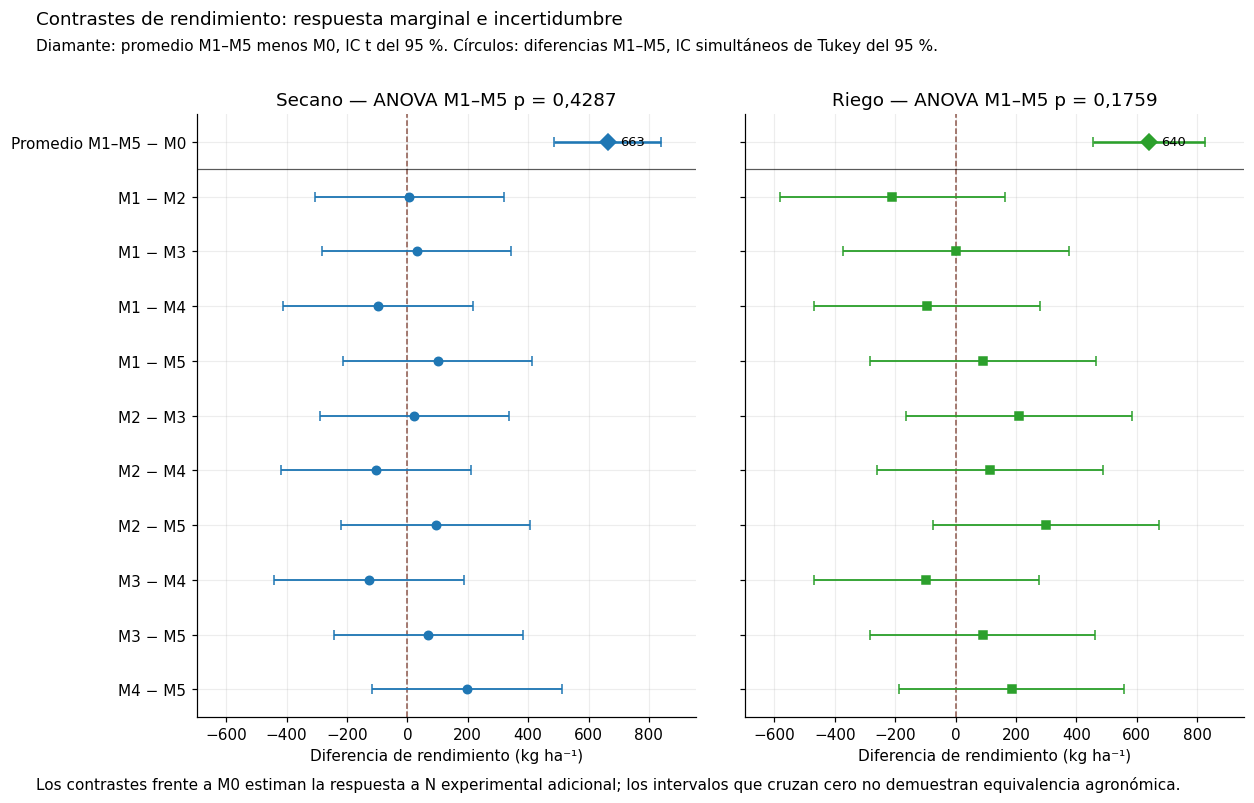

In [14]:
def average_fertilized_minus_control(
    result: RCBDResult,
) -> dict[str, float]:
    _, vectors, covariance = adjusted_treatment_means(
        result.fit,
        treatments=TREATMENTS,
    )
    fertilized_vector = np.mean(
        np.vstack([vectors[treatment] for treatment in FERTILIZED]),
        axis=0,
    )
    contrast = fertilized_vector - vectors["M0"]
    estimate = float(contrast @ result.fit.params.to_numpy())
    se = float(np.sqrt(contrast @ covariance @ contrast))
    half_width = float(cast(Any, stats.t.ppf(0.975, result.fit.df_resid))) * se
    return {
        "difference": estimate,
        "ci_low": estimate - half_width,
        "ci_high": estimate + half_width,
    }


def build_yield_contrast_table() -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for sector in SECTORS:
        all_result = final_rcbd_models[("clean_yield_kg_ha", sector, "M0–M5")]
        aggregate = average_fertilized_minus_control(all_result)
        rows.append(
            {
                "sector": sector,
                "contrast": "Promedio M1–M5 − M0",
                **aggregate,
                "interval_type": "IC t puntual del 95 %",
                "aggregate": True,
            }
        )

        calendar_result = final_rcbd_models[("clean_yield_kg_ha", sector, "M1–M5")]
        for raw_row in calendar_result.pairwise.itertuples(index=False):
            row = cast(Any, raw_row)
            rows.append(
                {
                    "sector": sector,
                    "contrast": f"{row.group1} − {row.group2}",
                    "difference": row.difference,
                    "ci_low": row.ci_low,
                    "ci_high": row.ci_high,
                    "interval_type": "IC simultáneo de Tukey del 95 %",
                    "aggregate": False,
                }
            )
    return pd.DataFrame(rows)


yield_contrasts = build_yield_contrast_table()
display_output(yield_contrasts.round(2))


def plot_yield_contrast_points(
    ax: Any,
    *,
    sector: str,
    sector_table: pd.DataFrame,
    contrast_order: Sequence[str],
    y_positions: np.ndarray,
) -> None:
    for position, contrast_label in zip(y_positions, contrast_order, strict=True):
        row = cast(Any, sector_table.loc[contrast_label])
        aggregate = bool(row["aggregate"])
        estimate = float(row["difference"])
        ax.errorbar(
            estimate,
            position,
            xerr=[
                [estimate - float(row["ci_low"])],
                [float(row["ci_high"]) - estimate],
            ],
            color=SECTOR_COLORS[sector],
            marker="D" if aggregate else SECTOR_MARKERS[sector],
            markersize=7 if aggregate else 5.5,
            linestyle="none",
            elinewidth=1.7 if aggregate else 1.2,
            capsize=3,
            zorder=3,
        )
        if aggregate:
            ax.annotate(
                f"{estimate:.0f}",
                (estimate, position),
                xytext=(8, 0),
                textcoords="offset points",
                va="center",
                fontsize=8.5,
            )


def configure_yield_contrast_axis(
    ax: Any,
    *,
    sector: str,
    panel_index: int,
    contrast_order: Sequence[str],
    y_positions: np.ndarray,
    x_limits: tuple[float, float],
) -> None:
    ax.axvline(0, color=PLOT_PALETTE[5], linestyle="--", linewidth=1)
    ax.axhline(
        0.5,
        color=mpl.rcParams["axes.edgecolor"],
        linewidth=0.8,
        alpha=0.65,
    )
    global_p = float(
        cast(
            Any,
            final_rcbd_models[("clean_yield_kg_ha", sector, "M1–M5")].anova.loc[
                "C(treatment)", "PR(>F)"
            ],
        )
    )
    ax.set_title(f"{sector} — ANOVA M1–M5 p = {global_p:.4f}".replace(".", ","))
    ax.set_xlim(*x_limits)
    ax.set_xlabel("Diferencia de rendimiento (kg ha⁻¹)")
    ax.set_yticks(y_positions, contrast_order)
    ax.tick_params(axis="y", labelleft=panel_index == 0)
    if panel_index == 0:
        ax.invert_yaxis()


def plot_yield_contrasts() -> None:
    contrast_order = [
        "Promedio M1–M5 − M0",
        *[f"{first} − {second}" for first, second in combinations(FERTILIZED, 2)],
    ]
    y_positions = np.arange(len(contrast_order), dtype=float)
    all_limits = yield_contrasts[["ci_low", "ci_high"]].to_numpy(dtype=float)
    lower = min(0.0, float(np.nanmin(all_limits)))
    upper = max(0.0, float(np.nanmax(all_limits)))
    padding = 0.08 * (upper - lower)
    x_limits = (lower - padding, upper + padding)

    fig, axes = mpl.subplots(1, 2, figsize=(12.2, 7.3), sharex=True, sharey=True)
    axes_array = np.asarray(axes).ravel()
    for panel_index, sector in enumerate(SECTORS):
        ax = axes_array[panel_index]
        sector_table = yield_contrasts.loc[
            yield_contrasts["sector"].eq(sector)
        ].set_index("contrast")
        plot_yield_contrast_points(
            ax,
            sector=sector,
            sector_table=sector_table,
            contrast_order=contrast_order,
            y_positions=y_positions,
        )
        configure_yield_contrast_axis(
            ax,
            sector=sector,
            panel_index=panel_index,
            contrast_order=contrast_order,
            y_positions=y_positions,
            x_limits=x_limits,
        )

    fig.suptitle(
        "Contrastes de rendimiento: respuesta marginal e incertidumbre",
        x=0.08,
        y=0.99,
        ha="left",
    )
    fig.text(
        0.08,
        0.94,
        (
            "Diamante: promedio M1–M5 menos M0, IC t del 95 %. "
            "Círculos: diferencias M1–M5, IC simultáneos de Tukey del 95 %."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.text(
        0.08,
        0.02,
        (
            "Los contrastes frente a M0 estiman la respuesta a N experimental adicional; "
            "los intervalos que cruzan cero no demuestran equivalencia agronómica."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.subplots_adjust(
        left=0.20,
        right=0.98,
        bottom=0.11,
        top=0.86,
        wspace=0.10,
    )
    save_figure(fig, "anexo_contrastes_rendimiento")
    mpl.show()
    mpl.close(fig)


plot_yield_contrasts()

### 5.3 Componentes del rendimiento: datos individuales e incertidumbre

La figura se restringe a M1–M5 y muestra densidad de panojas, número **estimado** de semillas por panoja y peso de mil semillas. Los puntos son parcelas individuales y los símbolos grandes son medias ajustadas por bloque con intervalos puntuales del 95 %. Esta representación es preferible a deducir “compensación” desde una única correlación: permite ver cada componente y su incertidumbre, manteniendo explícito que semillas por panoja fue reconstruido algebraicamente.

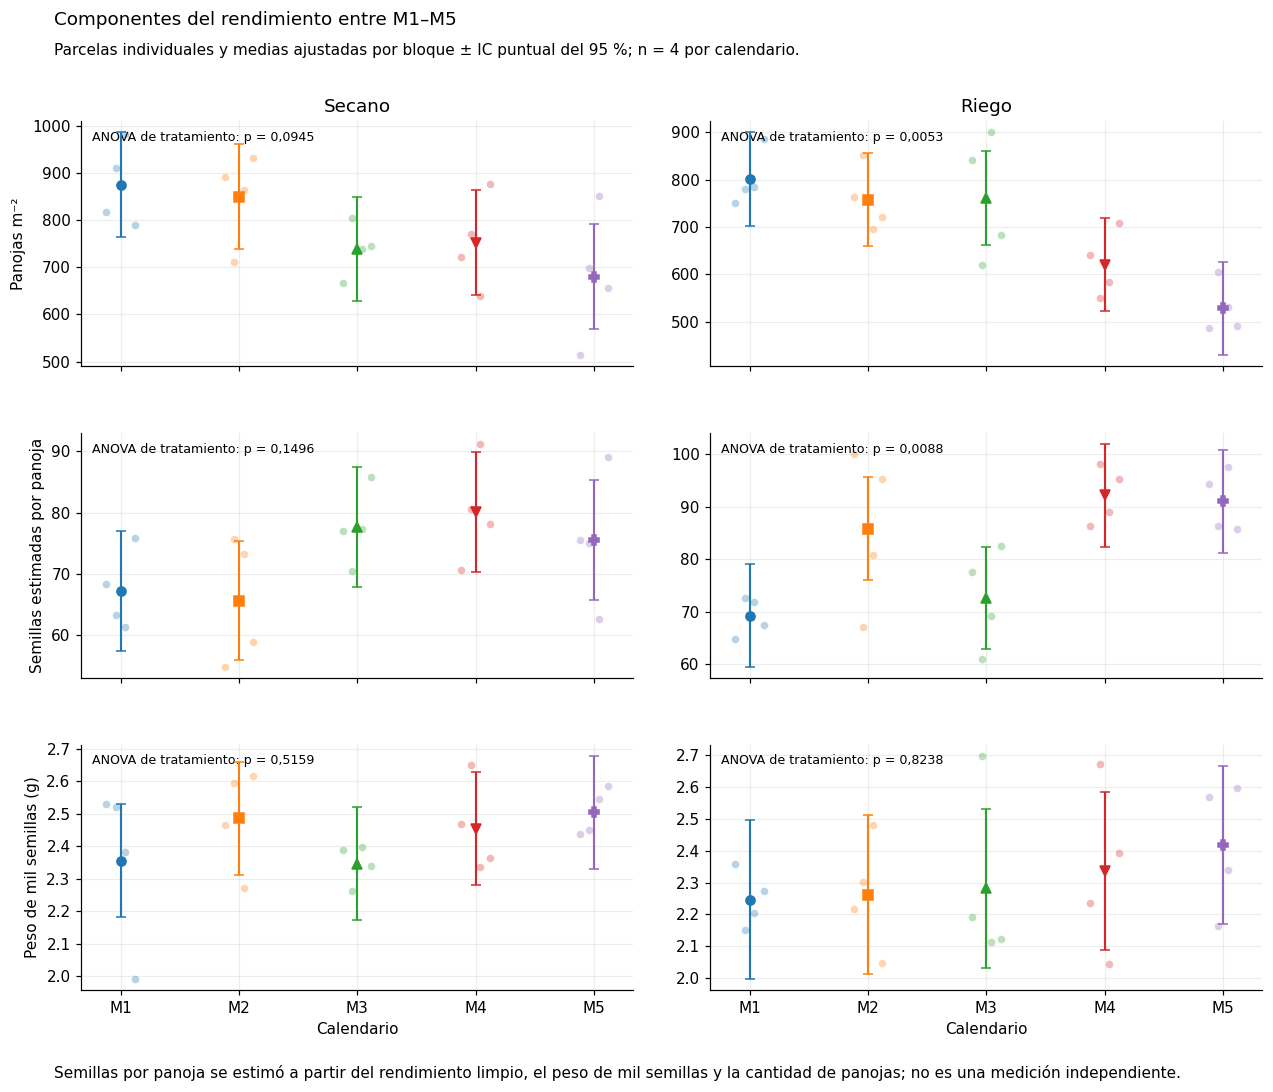

In [15]:
COMPONENT_OUTCOMES = [
    "panicle_density_m2",
    "estimated_seeds_per_panicle",
    "w1000_g",
]


def plot_harvest_component_points(
    ax: Any,
    *,
    raw: pd.DataFrame,
    means: pd.DataFrame,
    outcome: str,
    treatment_positions: np.ndarray,
    block_offsets: dict[str, float],
) -> None:
    for position, treatment in zip(treatment_positions, FERTILIZED, strict=True):
        observations = raw.loc[raw["treatment"].astype(str).eq(treatment)].sort_values(
            "block"
        )
        point_positions = np.asarray(
            [position + block_offsets[str(block)] for block in observations["block"]]
        )
        ax.scatter(
            point_positions,
            observations[outcome],
            color=TREATMENT_COLORS[treatment],
            alpha=0.32,
            s=25,
            linewidths=0,
            zorder=2,
        )
        mean_row = cast(Any, means.loc[treatment])
        ax.errorbar(
            position,
            float(mean_row["estimate"]),
            yerr=[
                [float(mean_row["estimate"] - mean_row["ci_low"])],
                [float(mean_row["ci_high"] - mean_row["estimate"])],
            ],
            color=TREATMENT_COLORS[treatment],
            marker=TREATMENT_MARKERS[treatment],
            markersize=6,
            linestyle="none",
            elinewidth=1.4,
            capsize=3,
            zorder=4,
        )


def configure_harvest_component_axis(
    ax: Any,
    *,
    result: RCBDResult,
    outcome: str,
    sector: str,
    row_index: int,
    column_index: int,
    treatment_positions: np.ndarray,
) -> None:
    global_p = float(cast(Any, result.anova.loc["C(treatment)", "PR(>F)"]))
    p_text = "< 0,0001" if global_p < 0.0001 else f"= {global_p:.4f}".replace(".", ",")
    ax.text(
        0.02,
        0.96,
        f"ANOVA de tratamiento: p {p_text}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.3,
    )
    if row_index == 0:
        ax.set_title(sector)
    if column_index == 0:
        ax.set_ylabel(OUTCOME_LABELS[outcome])
    if row_index == len(COMPONENT_OUTCOMES) - 1:
        ax.set_xticks(treatment_positions, FERTILIZED)
        ax.set_xlabel("Calendario")
    else:
        ax.tick_params(axis="x", labelbottom=False)


def plot_harvest_component_panel(
    ax: Any,
    *,
    outcome: str,
    sector: str,
    row_index: int,
    column_index: int,
    treatment_positions: np.ndarray,
    block_offsets: dict[str, float],
) -> None:
    raw = data.harvest.loc[
        data.harvest["sector"].astype(str).eq(sector)
        & data.harvest["treatment"].astype(str).isin(FERTILIZED)
    ]
    result = final_rcbd_models[(outcome, sector, "M1–M5")]
    means = result.means.set_index("treatment")
    plot_harvest_component_points(
        ax,
        raw=raw,
        means=means,
        outcome=outcome,
        treatment_positions=treatment_positions,
        block_offsets=block_offsets,
    )
    configure_harvest_component_axis(
        ax,
        result=result,
        outcome=outcome,
        sector=sector,
        row_index=row_index,
        column_index=column_index,
        treatment_positions=treatment_positions,
    )


def plot_harvest_component_panels() -> None:
    treatment_positions = np.arange(len(FERTILIZED), dtype=float)
    block_offsets = dict(
        zip(BLOCKS, np.linspace(-0.12, 0.12, len(BLOCKS)), strict=True)
    )
    fig, axes = mpl.subplots(
        len(COMPONENT_OUTCOMES),
        len(SECTORS),
        figsize=(12.2, 10.0),
        sharex=True,
        squeeze=False,
    )
    axes_array = np.asarray(axes)
    for row_index, outcome in enumerate(COMPONENT_OUTCOMES):
        for column_index, sector in enumerate(SECTORS):
            plot_harvest_component_panel(
                axes_array[row_index, column_index],
                outcome=outcome,
                sector=sector,
                row_index=row_index,
                column_index=column_index,
                treatment_positions=treatment_positions,
                block_offsets=block_offsets,
            )

    fig.suptitle(
        "Componentes del rendimiento entre M1–M5",
        x=0.08,
        y=0.99,
        ha="left",
    )
    fig.text(
        0.08,
        0.95,
        (
            "Parcelas individuales y medias ajustadas por bloque ± IC puntual "
            "del 95 %; n = 4 por calendario."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.text(
        0.08,
        0.02,
        (
            "Semillas por panoja se estimó a partir del rendimiento limpio, el peso "
            "de mil semillas y la cantidad de panojas; no es una medición independiente."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        bottom=0.10,
        top=0.89,
        hspace=0.27,
        wspace=0.14,
    )
    save_figure(fig, "figura_06_componentes_del_rendimiento")
    mpl.show()
    mpl.close(fig)


plot_harvest_component_panels()

### 5.4 Relación descriptiva entre los componentes reconstruidos

La figura es útil para visualizar el patrón, pero no convierte el número estimado de semillas por panoja en una medición independiente.

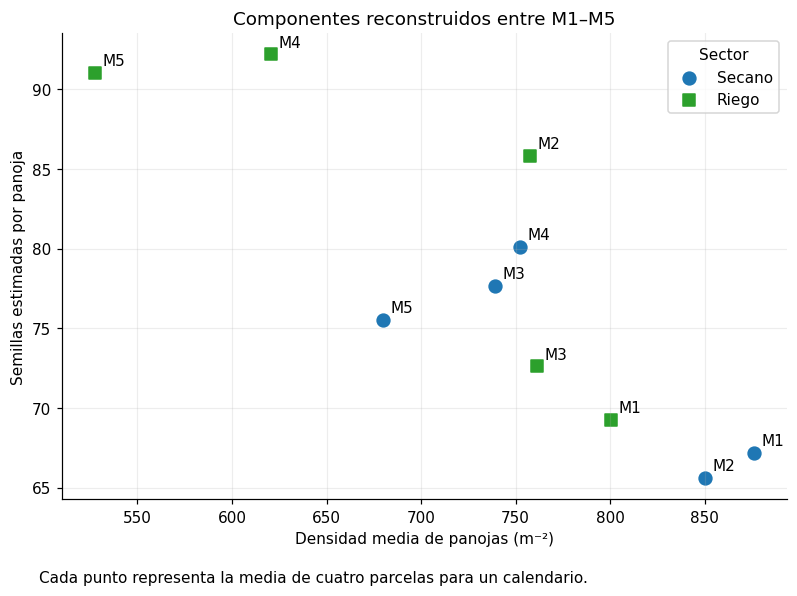

In [16]:
component_means = (
    data.harvest.loc[data.harvest["treatment"].astype(str).isin(FERTILIZED)]
    .groupby(["sector", "treatment"], observed=True)[
        ["panicle_density_m2", "estimated_seeds_per_panicle"]
    ]
    .mean()
    .reset_index()
)

fig, ax = mpl.subplots(figsize=(8.5, 5.8))
for sector in SECTORS:
    subset = component_means.loc[component_means["sector"].astype(str).eq(sector)]
    ax.scatter(
        subset["panicle_density_m2"],
        subset["estimated_seeds_per_panicle"],
        color=SECTOR_COLORS[sector],
        marker=SECTOR_MARKERS[sector],
        s=70,
        label=sector,
    )
    for raw_row in subset.itertuples(index=False):
        row = cast(Any, raw_row)
        ax.annotate(
            str(row.treatment),
            (row.panicle_density_m2, row.estimated_seeds_per_panicle),
            xytext=(5, 5),
            textcoords="offset points",
        )
ax.set_xlabel("Densidad media de panojas (m⁻²)")
ax.set_ylabel("Semillas estimadas por panoja")
ax.set_title("Componentes reconstruidos entre M1–M5")
ax.legend(title="Sector")
fig.text(
    0.10,
    0.02,
    "Cada punto representa la media de cuatro parcelas para un calendario.",
    color=mpl.rcParams["axes.labelcolor"],
)
fig.subplots_adjust(bottom=0.15)
mpl.show()
mpl.close(fig)

### 5.5 Precisión técnica del peso de 100 semillas

,count,mean,std,min,25%,50%,75%,max
technical_cv_pct,48.0000,3.1740,1.5370,0.5650,2.3460,2.9940,4.1010,7.0920


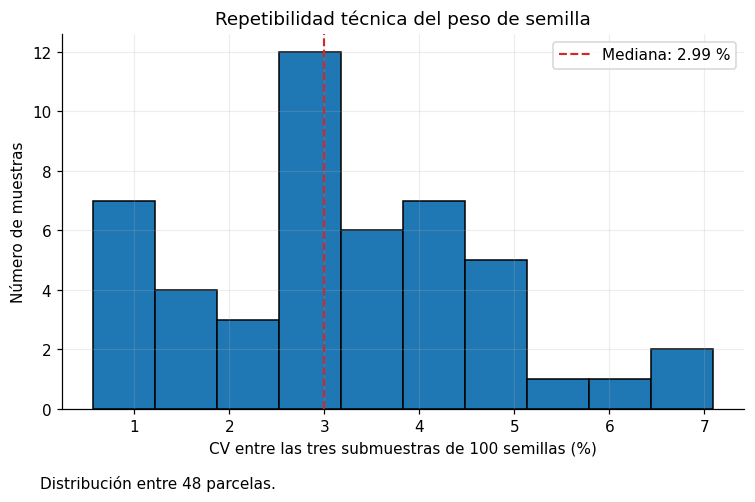

In [17]:
seed_repeatability = data.harvest[
    [
        "sample_id",
        "sector",
        "block",
        "treatment",
        "w100_1_g",
        "w100_2_g",
        "w100_3_g",
    ]
].copy()
weights = seed_repeatability[["w100_1_g", "w100_2_g", "w100_3_g"]]
seed_repeatability["technical_cv_pct"] = (
    100.0 * weights.std(axis=1, ddof=1) / weights.mean(axis=1)
)
display_output(seed_repeatability["technical_cv_pct"].describe().to_frame().T.round(3))

fig, ax = mpl.subplots(figsize=(8, 4.8))
ax.hist(
    seed_repeatability["technical_cv_pct"],
    bins=10,
    color=PLOT_PALETTE[0],
    edgecolor=mpl.rcParams["axes.edgecolor"],
)
median_cv = float(cast(Any, seed_repeatability["technical_cv_pct"].median()))
ax.axvline(
    median_cv,
    color=PLOT_PALETTE[3],
    linestyle="--",
    linewidth=1.4,
    label=f"Mediana: {median_cv:.2f} %",
)
ax.set_xlabel("CV entre las tres submuestras de 100 semillas (%)")
ax.set_ylabel("Número de muestras")
ax.set_title("Repetibilidad técnica del peso de semilla")
ax.legend()
fig.text(
    0.10,
    0.02,
    f"Distribución entre {len(seed_repeatability)} parcelas.",
    color=mpl.rcParams["axes.labelcolor"],
)
fig.subplots_adjust(bottom=0.17)
mpl.show()
mpl.close(fig)

## 6. Diagnóstico de los modelos clásicos

La tesis examinó normalidad, homogeneidad y observaciones influyentes sin eliminar automáticamente registros. Aquí se ofrecen diagnósticos reproducibles. Con cuatro repeticiones por tratamiento, las pruebas formales tienen poca potencia; deben leerse junto con los gráficos y la sensibilidad.

In [18]:
def diagnostic_row(
    result: RCBDResult,
    *,
    sector: str,
    date: pd.Timestamp | None,
    comparison: str,
) -> dict[str, object]:
    residuals = np.asarray(result.fit.resid)
    shapiro_p = stats.shapiro(residuals).pvalue if len(residuals) >= 3 else np.nan
    groups = [
        group[result.outcome].dropna().to_numpy()
        for _, group in result.frame.groupby("treatment", observed=True)
    ]
    levene_p = (
        stats.levene(*groups, center="median").pvalue
        if all(len(group) >= 2 for group in groups)
        else np.nan
    )
    influence = result.fit.get_influence()
    studentized = influence.resid_studentized_external
    cooks = influence.cooks_distance[0]
    response = result.frame[result.outcome]
    q1, q3 = response.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_flag_count = int(
        ((response < q1 - 1.5 * iqr) | (response > q3 + 1.5 * iqr)).sum()
    )
    return {
        "outcome": result.outcome,
        "label": OUTCOME_LABELS.get(result.outcome, result.outcome),
        "sector": sector,
        "date": date,
        "comparison": comparison,
        "n": len(result.frame),
        "shapiro_p": shapiro_p,
        "levene_median_p": levene_p,
        "max_abs_studentized": float(np.nanmax(np.abs(studentized))),
        "max_cooks_d": float(np.nanmax(cooks)),
        "cooks_4_over_n_count": int(np.sum(cooks > 4.0 / len(result.frame))),
        "iqr_flag_count": iqr_flag_count,
    }


diagnostic_rows: list[dict[str, object]] = []
for (outcome, date, sector, comparison), result in longitudinal_rcbd_models.items():
    if comparison == "M1–M5":
        diagnostic_rows.append(
            diagnostic_row(
                result,
                sector=sector,
                date=date,
                comparison=comparison,
            )
        )
for (outcome, sector, comparison), result in final_rcbd_models.items():
    if comparison == "M1–M5" and outcome in FINAL_OUTCOMES:
        diagnostic_rows.append(
            diagnostic_row(
                result,
                sector=sector,
                date=None,
                comparison=comparison,
            )
        )

diagnostics = pd.DataFrame(diagnostic_rows)
diagnostics["potential_flag"] = (
    diagnostics["shapiro_p"].lt(ALPHA)
    | diagnostics["levene_median_p"].lt(ALPHA)
    | diagnostics["max_abs_studentized"].gt(3.0)
    | diagnostics["cooks_4_over_n_count"].gt(0)
    | diagnostics["iqr_flag_count"].gt(0)
)

display_output(
    diagnostics.loc[diagnostics["potential_flag"]]
    .sort_values(["label", "sector", "date"])
    .round(4)
)

,outcome,label,sector,date,comparison,n,shapiro_p,levene_median_p,max_abs_studentized,max_cooks_d,cooks_4_over_n_count,iqr_flag_count,potential_flag
1,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,2025-09-16,M1–M5,20,0.8290,0.7286,3.4701,0.5226,3,0,True
3,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,2025-10-20,M1–M5,20,0.4063,0.9952,2.1647,0.2987,4,0,True
5,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,2025-11-12,M1–M5,20,0.8006,0.6288,2.4238,0.3481,2,1,True
0,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,2025-09-16,M1–M5,20,0.2364,0.0518,3.9123,0.5818,3,1,True
2,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,2025-10-20,M1–M5,20,0.0567,0.5960,2.3167,0.3279,2,0,True
4,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,2025-11-12,M1–M5,20,0.9146,0.6226,2.2474,0.3147,2,0,True
19,nni_revised,INN revisado,Riego,2025-09-16,M1–M5,20,0.9914,0.4823,2.3549,0.3352,2,1,True
21,nni_revised,INN revisado,Riego,2025-10-20,M1–M5,20,0.5933,0.2922,2.0760,0.2815,2,2,True
23,nni_revised,INN revisado,Riego,2025-11-12,M1–M5,20,0.3241,0.0408,2.2278,0.3109,1,0,True
18,nni_revised,INN revisado,Secano,2025-09-16,M1–M5,19,0.6472,0.6700,2.3372,0.3295,2,0,True


### 6.1 Diagnóstico gráfico del resultado primario

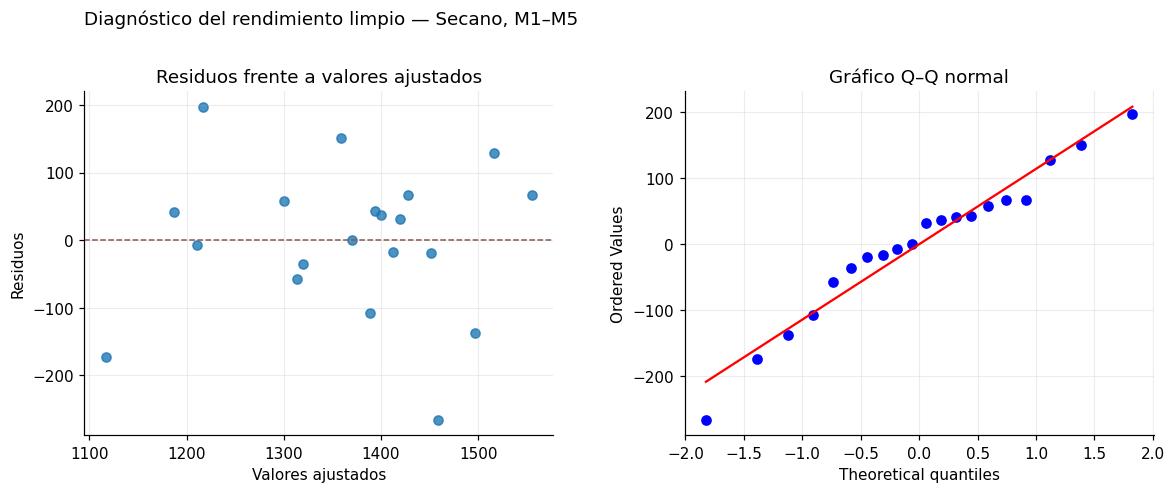

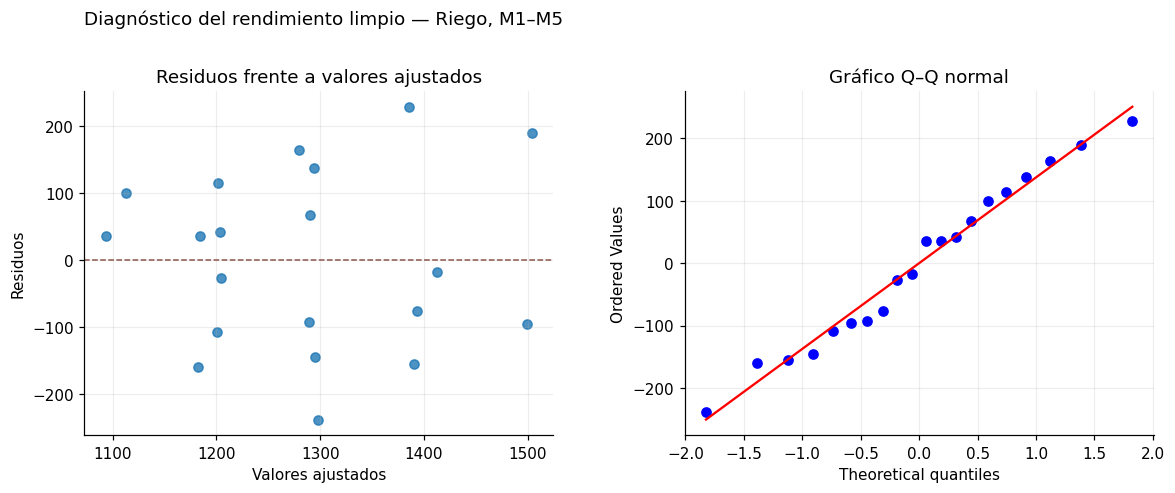

In [19]:
def residual_diagnostic_plots(result: RCBDResult, *, title_prefix: str) -> None:
    fitted = np.asarray(result.fit.fittedvalues)
    residuals = np.asarray(result.fit.resid)

    fig, axes = mpl.subplots(1, 2, figsize=(10.8, 4.6))
    residual_ax, qq_ax = np.asarray(axes).ravel()
    residual_ax.scatter(fitted, residuals, color=PLOT_PALETTE[0], alpha=0.8)
    residual_ax.axhline(
        0,
        color=PLOT_PALETTE[5],
        linestyle="--",
        linewidth=1,
    )
    residual_ax.set_xlabel("Valores ajustados")
    residual_ax.set_ylabel("Residuos")
    residual_ax.set_title("Residuos frente a valores ajustados")

    stats.probplot(residuals, dist="norm", plot=qq_ax)
    qq_ax.set_title("Gráfico Q–Q normal")
    fig.suptitle(title_prefix, x=0.08, y=0.98, ha="left")
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.82, wspace=0.28)
    mpl.show()
    mpl.close(fig)


for sector in SECTORS:
    residual_diagnostic_plots(
        final_rcbd_models[("clean_yield_kg_ha", sector, "M1–M5")],
        title_prefix=f"Diagnóstico del rendimiento limpio — {sector}, M1–M5",
    )

## 7. Sensibilidad del dato faltante de N

La observación principal permanece ausente. La siguiente celda reproduce correctamente la imputación de una celda faltante en un diseño de bloques completos al azar:

$$
\hat{x}=\frac{rB+tT-G}{(r-1)(t-1)}.
$$

La sensibilidad se ejecuta en una copia del conjunto de datos y nunca reemplaza el dato observado.

In [20]:
def rcbd_missing_cell_estimate(
    frame: pd.DataFrame,
    *,
    value_column: str,
    missing_treatment: str,
    missing_block: str,
    r_blocks: int,
    t_treatments: int,
) -> float:
    observed = frame.dropna(subset=[value_column]).copy()
    block_total = observed.loc[
        observed["block"].astype(str).eq(missing_block), value_column
    ].sum()
    treatment_total = observed.loc[
        observed["treatment"].astype(str).eq(missing_treatment), value_column
    ].sum()
    grand_total = observed[value_column].sum()
    return float(
        (r_blocks * block_total + t_treatments * treatment_total - grand_total)
        / ((r_blocks - 1) * (t_treatments - 1))
    )


sep_secano = data.longitudinal.loc[
    data.longitudinal["date"].astype("datetime64[ns]").eq(DATES[0])
    & data.longitudinal["sector"].astype(str).eq("Secano")
].copy()

imputed_values = {
    "n_pct": rcbd_missing_cell_estimate(
        sep_secano,
        value_column="n_pct",
        missing_treatment="M1",
        missing_block="R4",
        r_blocks=4,
        t_treatments=6,
    ),
    "adf_pct": rcbd_missing_cell_estimate(
        sep_secano,
        value_column="adf_pct",
        missing_treatment="M1",
        missing_block="R4",
        r_blocks=4,
        t_treatments=6,
    ),
    "ndf_pct": rcbd_missing_cell_estimate(
        sep_secano,
        value_column="ndf_pct",
        missing_treatment="M1",
        missing_block="R4",
        r_blocks=4,
        t_treatments=6,
    ),
}
display_output(pd.Series(imputed_values, name="imputación correcta").to_frame())
assert_close(imputed_values["n_pct"], 2.485788, tolerance=1e-6)

imputed_sep = sep_secano.copy()
missing_mask = imputed_sep["treatment"].astype(str).eq("M1") & imputed_sep[
    "block"
].astype(str).eq("R4")
imputed_sep.loc[missing_mask, "n_pct"] = imputed_values["n_pct"]
imputed_sep.loc[missing_mask, "adf_pct"] = imputed_values["adf_pct"]
imputed_sep.loc[missing_mask, "ndf_pct"] = imputed_values["ndf_pct"]
imputed_sep.loc[missing_mask, "q_kg_n_ha"] = (
    imputed_sep.loc[missing_mask, "biomass_kg_ha_used"]
    * imputed_sep.loc[missing_mask, "n_pct"]
    / 100.0
)
biomass_t = imputed_sep.loc[missing_mask, "biomass_kg_ha_used"] / 1000.0
imputed_sep.loc[missing_mask, "nni_revised"] = imputed_sep.loc[
    missing_mask, "n_pct"
] / (3.93 * biomass_t.pow(-0.42))

sensitivity_rows: list[dict[str, object]] = []
for outcome in ["n_pct", "q_kg_n_ha", "nni_revised"]:
    for frame_name, frame in [("observado", sep_secano), ("imputado", imputed_sep)]:
        result = fit_rcbd(frame, outcome=outcome, treatments=FERTILIZED)
        sensitivity_rows.append(
            {
                "outcome": OUTCOME_LABELS[outcome],
                "scenario": frame_name,
                "p_M1_M5": result.anova.loc["C(treatment)", "PR(>F)"],
            }
        )
display_output(pd.DataFrame(sensitivity_rows).round(6))

,imputación correcta
n_pct,2.4858
adf_pct,32.7409
ndf_pct,55.0156


,outcome,scenario,p_M1_M5
0,N en biomasa (%),observado,0.2518
1,N en biomasa (%),imputado,0.1534
2,N acumulado (kg N ha⁻¹),observado,0.0061
3,N acumulado (kg N ha⁻¹),imputado,0.0032
4,INN revisado,observado,0.0071
5,INN revisado,imputado,0.0033


## 8. Análisis conjunto descriptivo entre sectores

Para M1–M5 se ajusta:

$$
Y \sim momento \times sector + bloque(sector).
$$

La interacción describe si el patrón relativo de M1–M5 difiere entre **estos dos sectores**. El efecto principal del sector no se interpreta como un efecto causal del riego.

In [21]:
def fit_joint_sector_model(
    frame: pd.DataFrame,
    *,
    outcome: str,
    treatments: Sequence[str] = FERTILIZED,
) -> tuple[Any, pd.DataFrame, pd.DataFrame]:
    subset = (
        frame.loc[frame["treatment"].astype(str).isin(treatments)]
        .dropna(subset=[outcome])
        .copy()
    )
    subset["treatment"] = categorical(subset["treatment"], treatments)
    subset["sector"] = categorical(subset["sector"], SECTORS)
    subset["block"] = categorical(subset["block"], BLOCKS)
    fit = smf_api.ols(
        f"{outcome} ~ C(treatment) * C(sector) + C(sector):C(block)",
        data=subset,
    ).fit()
    anova = sm_api.stats.anova_lm(fit, typ=2)
    return fit, anova, subset


joint_rows: list[dict[str, object]] = []
for outcome in LONGITUDINAL_OUTCOMES:
    for date in DATES:
        frame = data.longitudinal.loc[
            data.longitudinal["date"].astype("datetime64[ns]").eq(date)
        ].copy()
        fit, anova, subset = fit_joint_sector_model(frame, outcome=outcome)
        joint_rows.append(
            {
                "outcome": outcome,
                "label": OUTCOME_LABELS[outcome],
                "date": date,
                "n": len(subset),
                "p_treatment": anova.loc["C(treatment)", "PR(>F)"],
                "p_sector": anova.loc["C(sector)", "PR(>F)"],
                "p_treatment_x_sector": anova.loc["C(treatment):C(sector)", "PR(>F)"],
            }
        )

for outcome in FINAL_OUTCOMES:
    fit, anova, subset = fit_joint_sector_model(data.harvest, outcome=outcome)
    joint_rows.append(
        {
            "outcome": outcome,
            "label": OUTCOME_LABELS[outcome],
            "date": pd.NaT,
            "n": len(subset),
            "p_treatment": anova.loc["C(treatment)", "PR(>F)"],
            "p_sector": anova.loc["C(sector)", "PR(>F)"],
            "p_treatment_x_sector": anova.loc["C(treatment):C(sector)", "PR(>F)"],
        }
    )

joint_results = pd.DataFrame(joint_rows)
joint_results["date_label"] = joint_results["date"].map(DATE_LABELS)
display_output(
    joint_results[
        [
            "label",
            "date_label",
            "n",
            "p_treatment",
            "p_treatment_x_sector",
            "p_sector",
        ]
    ].round(4)
)

# Guardrails: la tabla conjunta de INN debe reproducir los valores de la tesis.
expected_nni_joint = {
    pd.Timestamp("2025-09-16"): (0.000046, 0.4968),
    pd.Timestamp("2025-10-20"): (0.0281, 0.0508),
    pd.Timestamp("2025-11-12"): (0.0082, 0.5687),
}
for date, (expected_treatment, expected_interaction) in expected_nni_joint.items():
    row = joint_results.loc[
        joint_results["outcome"].eq("nni_revised") & joint_results["date"].eq(date)
    ].iloc[0]
    assert_close(row["p_treatment"], expected_treatment, tolerance=5e-4)
    assert_close(row["p_treatment_x_sector"], expected_interaction, tolerance=5e-4)
print("El análisis conjunto de INN reproduce la tabla de la tesis.")

,label,date_label,n,p_treatment,p_treatment_x_sector,p_sector
0,Biomasa aérea (kg MS ha⁻¹),16 sep,40,0.0000,0.0621,0.9837
1,Biomasa aérea (kg MS ha⁻¹),20 oct,40,0.0333,0.6917,0.6228
2,Biomasa aérea (kg MS ha⁻¹),12 nov,40,0.0044,0.8938,0.8317
3,N en biomasa (%),16 sep,39,0.0281,0.3135,0.7598
4,N en biomasa (%),20 oct,40,0.0001,0.0794,0.7864
5,N en biomasa (%),12 nov,40,0.0017,0.8367,0.4278
6,N acumulado (kg N ha⁻¹),16 sep,39,0.0000,0.4603,0.8040
7,N acumulado (kg N ha⁻¹),20 oct,40,0.7454,0.1013,0.7964
8,N acumulado (kg N ha⁻¹),12 nov,40,0.0240,0.4872,0.6635
9,INN revisado,16 sep,39,0.0000,0.4968,0.9685


El análisis conjunto de INN reproduce la tabla de la tesis.


## 9. Correlaciones exploratorias: reproducción y extensión de auditoría

Primero se reproducen las correlaciones de Pearson con las 24 parcelas de cada sector y con las 48 parcelas combinadas. Después se muestran dos extensiones:

1. correlación restringida a M1–M5;
2. correlación entre residuos después de ajustar tratamiento y bloque.

La segunda distingue la separación entre grupos de tratamiento de la asociación entre parcelas comparables. No convierte la correlación en causal. Las variables que contienen el rendimiento en su fórmula continúan matemáticamente acopladas.

In [22]:
final_nutrition = data.longitudinal.loc[
    data.longitudinal["date"].astype("datetime64[ns]").eq(DATES[-1]),
    [
        "plot_id",
        "biomass_kg_ha_used",
        "n_pct",
        "q_kg_n_ha",
        "nni_revised",
    ],
]
final_merged = data.harvest.merge(
    final_nutrition,
    on="plot_id",
    how="left",
    validate="one_to_one",
    suffixes=("", "_nutrition"),
)

CORRELATION_VARIABLES = [
    "panicle_density_m2",
    "estimated_seeds_per_panicle",
    "w1000_g",
    "biomass_kg_ha_used_nutrition",
    "n_pct",
    "q_kg_n_ha",
    "harvest_index_pct",
    "cleaning_loss_pct",
]
CORRELATION_LABELS = {
    "panicle_density_m2": "Panojas m⁻²",
    "estimated_seeds_per_panicle": "Semillas estimadas por panoja*",
    "w1000_g": "Peso de mil semillas",
    "biomass_kg_ha_used_nutrition": "Biomasa final",
    "n_pct": "Concentración de N",
    "q_kg_n_ha": "N acumulado",
    "harvest_index_pct": "Índice de cosecha*",
    "cleaning_loss_pct": "Merma de limpieza*",
}


def pearson_row(frame: pd.DataFrame, x: str, y: str) -> tuple[float, float, int]:
    subset = frame[[x, y]].dropna()
    result = cast(Any, stats.pearsonr(subset[x], subset[y]))
    return float(result.statistic), float(result.pvalue), len(subset)


raw_correlation_rows: list[dict[str, object]] = []
for variable in CORRELATION_VARIABLES:
    for sector in ["Conjunto", *SECTORS]:
        frame = (
            final_merged
            if sector == "Conjunto"
            else final_merged.loc[final_merged["sector"].astype(str).eq(sector)]
        )
        r, p, n = pearson_row(frame, variable, "clean_yield_kg_ha")
        raw_correlation_rows.append(
            {
                "variable": CORRELATION_LABELS[variable],
                "sector": sector,
                "r": r,
                "p": p,
                "n": n,
            }
        )
raw_correlations = pd.DataFrame(raw_correlation_rows)
display_output(
    raw_correlations.pivot(index="variable", columns="sector", values="r").round(3)
)


def residualized_correlation(
    frame: pd.DataFrame, variable: str
) -> tuple[float, float, int]:
    subset = frame.dropna(subset=[variable, "clean_yield_kg_ha"]).copy()
    subset["treatment"] = categorical(subset["treatment"], TREATMENTS)
    subset["block"] = categorical(subset["block"], BLOCKS)
    x_fit = smf_api.ols(f"{variable} ~ C(treatment) + C(block)", data=subset).fit()
    y_fit = smf_api.ols(
        "clean_yield_kg_ha ~ C(treatment) + C(block)", data=subset
    ).fit()
    result = cast(Any, stats.pearsonr(x_fit.resid, y_fit.resid))
    return float(result.statistic), float(result.pvalue), len(subset)


audit_correlation_rows: list[dict[str, object]] = []
for variable in [
    "biomass_kg_ha_used_nutrition",
    "n_pct",
    "q_kg_n_ha",
]:
    for sector in SECTORS:
        sector_frame = final_merged.loc[
            final_merged["sector"].astype(str).eq(sector)
        ].copy()
        all_r, all_p, all_n = pearson_row(sector_frame, variable, "clean_yield_kg_ha")
        fertilized_frame = sector_frame.loc[
            sector_frame["treatment"].astype(str).isin(FERTILIZED)
        ]
        fert_r, fert_p, fert_n = pearson_row(
            fertilized_frame, variable, "clean_yield_kg_ha"
        )
        adjusted_r, adjusted_p, adjusted_n = residualized_correlation(
            sector_frame, variable
        )
        audit_correlation_rows.append(
            {
                "variable": CORRELATION_LABELS[variable],
                "sector": sector,
                "raw_r": all_r,
                "raw_p": all_p,
                "M1_M5_r": fert_r,
                "M1_M5_p": fert_p,
                "adjusted_r": adjusted_r,
                "adjusted_p": adjusted_p,
            }
        )
correlation_audit = pd.DataFrame(audit_correlation_rows)
display_output(correlation_audit.round(4))

sector,Conjunto,Riego,Secano
variable,,,
Biomasa final,0.4560,0.2860,0.6260
Concentración de N,0.5520,0.5310,0.5650
Merma de limpieza*,-0.4510,-0.5200,-0.4150
N acumulado,0.6900,0.5830,0.7910
Panojas m⁻²,0.5310,0.4400,0.6060
Peso de mil semillas,0.1640,0.0440,0.2420
Semillas estimadas por panoja*,0.6930,0.7600,0.7580
Índice de cosecha*,0.7060,0.7940,0.6060


,variable,sector,raw_r,raw_p,M1_M5_r,M1_M5_p,adjusted_r,adjusted_p
0,Biomasa final,Secano,0.6259,0.0011,0.3763,0.1020,0.2929,0.1649
1,Biomasa final,Riego,0.2860,0.1754,0.1832,0.4394,-0.1073,0.6179
2,Concentración de N,Secano,0.5653,0.0040,0.0792,0.7398,-0.4034,0.0506
3,Concentración de N,Riego,0.5305,0.0077,0.0689,0.7728,0.0161,0.9404
4,N acumulado,Secano,0.7914,0.0000,0.4475,0.0479,0.0062,0.9770
5,N acumulado,Riego,0.5832,0.0028,0.2111,0.3716,-0.0944,0.6608


## 10. Extensión longitudinal con modelos mixtos

Para cada sector y variable se ajustan tres modelos por máxima verosimilitud, con intercepto aleatorio por parcela:

- **base:** `fecha + bloque`;
- **aditivo:** `fecha + tratamiento + bloque`;
- **completo:** `fecha × tratamiento + bloque`.

Se reportan pruebas de razón de verosimilitudes aproximadas para:

- efecto promedio del tratamiento: aditivo vs. base;
- interacción tratamiento × fecha: completo vs. aditivo;
- diferencia global de trayectorias: completo vs. base.

El resultado se estandariza antes del ajuste para mejorar la estabilidad numérica y se vuelve a expresar en sus unidades originales para las medias marginales. En varios modelos la varianza del intercepto aleatorio puede quedar en el límite cero; eso indica que, una vez incluidos fecha, tratamiento y bloque, los datos no contienen evidencia fuerte de heterogeneidad residual persistente entre parcelas. No invalida el análisis, pero aconseja no exagerar la complejidad longitudinal.

In [23]:
@dataclass
class MixedTrajectoryResult:
    outcome: str
    sector: str
    treatments: tuple[str, ...]
    frame: pd.DataFrame
    center: float
    scale: float
    base_fit: Any
    additive_fit: Any
    full_fit: Any
    summary: dict[str, object]


def fit_mixed_with_fallback(formula: str, frame: pd.DataFrame) -> Any:
    errors: list[str] = []
    for method in ["powell", "nm", "bfgs", "cg"]:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                fit = smf_api.mixedlm(
                    formula,
                    frame,
                    groups=frame["plot_id"],
                ).fit(
                    reml=False,
                    method=method,
                    maxiter=5000,
                    disp=False,
                )
            if np.isfinite(fit.llf):
                fit._audit_optimizer = method
                fit._audit_warnings = [str(item.message) for item in caught]
                return fit
        except Exception as exc:  # noqa: BLE001 - registrar fallas del optimizador
            errors.append(f"{method}: {type(exc).__name__}: {exc}")
    raise RuntimeError("No se pudo ajustar MixedLM. " + " | ".join(errors))


def likelihood_ratio(reduced: Any, full: Any) -> tuple[float, int, float]:
    statistic = max(0.0, 2.0 * (full.llf - reduced.llf))
    df = round(full.df_modelwc - reduced.df_modelwc)
    return statistic, df, float(chi2.sf(statistic, df))


def fit_longitudinal_mixed(
    frame: pd.DataFrame,
    *,
    outcome: str,
    sector: str,
    treatments: Sequence[str],
) -> MixedTrajectoryResult:
    subset = (
        frame.loc[
            frame["sector"].astype(str).eq(sector)
            & frame["treatment"].astype(str).isin(treatments)
        ]
        .dropna(subset=[outcome])
        .copy()
    )
    center = float(cast(Any, subset[outcome].mean()))
    scale = float(cast(Any, subset[outcome].std(ddof=0)))
    subset["y_z"] = (subset[outcome] - center) / scale
    subset["treatment"] = categorical(subset["treatment"], treatments)
    subset["block"] = categorical(subset["block"], BLOCKS)
    subset["date_label"] = categorical(
        subset["date_label"], [DATE_LABELS[date] for date in DATES]
    )

    base_formula = "y_z ~ C(date_label) + C(block)"
    additive_formula = "y_z ~ C(date_label) + C(treatment) + C(block)"
    full_formula = "y_z ~ C(date_label) * C(treatment) + C(block)"
    base_fit = fit_mixed_with_fallback(base_formula, subset)
    additive_fit = fit_mixed_with_fallback(additive_formula, subset)
    full_fit = fit_mixed_with_fallback(full_formula, subset)

    _, main_df, main_p = likelihood_ratio(base_fit, additive_fit)
    _, interaction_df, interaction_p = likelihood_ratio(additive_fit, full_fit)
    _, global_df, global_p = likelihood_ratio(base_fit, full_fit)
    random_variance = float(full_fit.cov_re.iloc[0, 0])
    summary: dict[str, object] = {
        "outcome": outcome,
        "label": OUTCOME_LABELS[outcome],
        "sector": sector,
        "comparison": "M1–M5" if list(treatments) == FERTILIZED else "M0–M5",
        "n": len(subset),
        "plots": subset["plot_id"].nunique(),
        "p_average_treatment": main_p,
        "df_average_treatment": main_df,
        "p_treatment_x_date": interaction_p,
        "df_treatment_x_date": interaction_df,
        "p_global_trajectory": global_p,
        "df_global_trajectory": global_df,
        "random_intercept_variance_z": random_variance,
        "random_effect_boundary": random_variance < 1e-6,
        "optimizer": getattr(full_fit, "_audit_optimizer", "unknown"),
        "converged": bool(full_fit.converged),
    }
    return MixedTrajectoryResult(
        outcome=outcome,
        sector=sector,
        treatments=tuple(treatments),
        frame=subset,
        center=center,
        scale=scale,
        base_fit=base_fit,
        additive_fit=additive_fit,
        full_fit=full_fit,
        summary=summary,
    )


mixed_models: dict[tuple[str, str, str], MixedTrajectoryResult] = {}
mixed_rows: list[dict[str, object]] = []
for outcome in LONGITUDINAL_OUTCOMES:
    for sector in SECTORS:
        for treatments in [FERTILIZED, TREATMENTS]:
            result = fit_longitudinal_mixed(
                data.longitudinal,
                outcome=outcome,
                sector=sector,
                treatments=treatments,
            )
            comparison = cast(str, result.summary["comparison"])
            mixed_models[(outcome, sector, comparison)] = result
            mixed_rows.append(result.summary)

mixed_summary = pd.DataFrame(mixed_rows)
display_output(
    mixed_summary[
        [
            "label",
            "sector",
            "comparison",
            "n",
            "plots",
            "p_average_treatment",
            "p_treatment_x_date",
            "p_global_trajectory",
            "random_intercept_variance_z",
            "random_effect_boundary",
            "converged",
        ]
    ].round(6)
)

,label,sector,comparison,n,plots,p_average_treatment,p_treatment_x_date,p_global_trajectory,random_intercept_variance_z,random_effect_boundary,converged
0,Biomasa aérea (kg MS ha⁻¹),Secano,M1–M5,60,20,0.0000,0.0746,0.0000,0.0000,True,True
1,Biomasa aérea (kg MS ha⁻¹),Secano,M0–M5,72,24,0.0000,0.0432,0.0000,0.0000,True,True
2,Biomasa aérea (kg MS ha⁻¹),Riego,M1–M5,60,20,0.0001,0.7863,0.0037,0.0000,True,True
3,Biomasa aérea (kg MS ha⁻¹),Riego,M0–M5,72,24,0.0000,0.0212,0.0000,0.0024,False,True
4,N en biomasa (%),Secano,M1–M5,59,20,0.3780,0.0088,0.0165,0.0000,True,True
5,N en biomasa (%),Secano,M0–M5,71,24,0.0000,0.0000,0.0000,0.0000,True,True
6,N en biomasa (%),Riego,M1–M5,60,20,0.0069,0.0000,0.0000,0.0000,True,True
7,N en biomasa (%),Riego,M0–M5,72,24,0.0000,0.0000,0.0000,0.0000,True,True
8,N acumulado (kg N ha⁻¹),Secano,M1–M5,59,20,0.0015,0.0004,0.0000,0.0000,True,True
9,N acumulado (kg N ha⁻¹),Secano,M0–M5,71,24,0.0000,0.0001,0.0000,0.0000,True,True


### 10.1 Medias marginales y datos observados del modelo longitudinal

Las figuras principales de esta extensión se restringen a M1–M5 y superponen las observaciones individuales con las medias marginales del modelo completo. Se promedian las predicciones fijas sobre los cuatro bloques. En este diseño casi balanceado, las estimaciones suelen quedar próximas a las medias observadas; el beneficio principal es evaluar directamente el efecto promedio del calendario y la interacción calendario × fecha.

La primera figura reúne crecimiento y captura de N. La segunda reúne concentración y estado nitrogenado. En ambas se informa, por sector, el valor de p del efecto promedio de tratamiento y de la interacción con la fecha. El 16 de septiembre M5 todavía había recibido solo 100 kg N ha⁻¹ experimentales; esa diferencia transitoria de dosis debe acompañar la interpretación.

,outcome,sector,date_label,early_minus_late,se,ci_low,ci_high,z,p_normal
0,Biomasa aérea (kg MS ha⁻¹),Secano,16 sep,"4,642.3750",797.0495,"3,080.1580","6,204.5920",5.8245,0.0000
1,Biomasa aérea (kg MS ha⁻¹),Secano,20 oct,"1,883.7500",797.0495,321.5330,"3,445.9670",2.3634,0.0181
2,Biomasa aérea (kg MS ha⁻¹),Secano,12 nov,"2,496.8553",797.0495,934.6383,"4,059.0723",3.1326,0.0017
3,Biomasa aérea (kg MS ha⁻¹),Riego,16 sep,"1,693.8750",588.6447,540.1314,"2,847.6186",2.8776,0.0040
4,Biomasa aérea (kg MS ha⁻¹),Riego,20 oct,"2,082.0000",588.6447,928.2564,"3,235.7436",3.5369,0.0004
5,Biomasa aérea (kg MS ha⁻¹),Riego,12 nov,"2,115.5855",588.6447,961.8420,"3,269.3291",3.5940,0.0003
6,N en biomasa (%),Secano,16 sep,0.1950,0.0889,0.0208,0.3692,2.1943,0.0282
7,N en biomasa (%),Secano,20 oct,-0.2433,0.0843,-0.4086,-0.0781,-2.8868,0.0039
8,N en biomasa (%),Secano,12 nov,-0.1213,0.0843,-0.2865,0.0439,-1.4390,0.1501
9,N en biomasa (%),Riego,16 sep,0.4394,0.0895,0.2640,0.6148,4.9109,0.0000


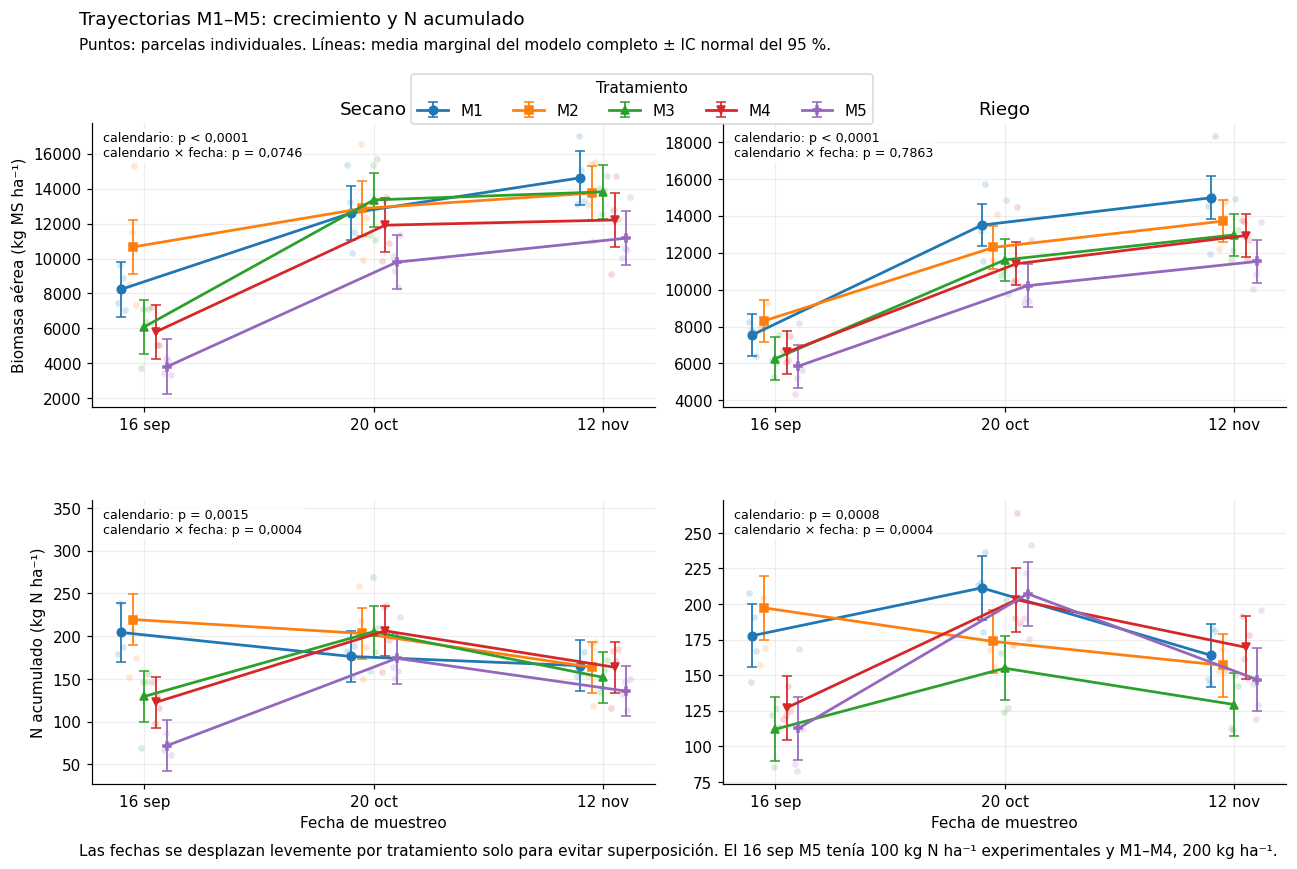

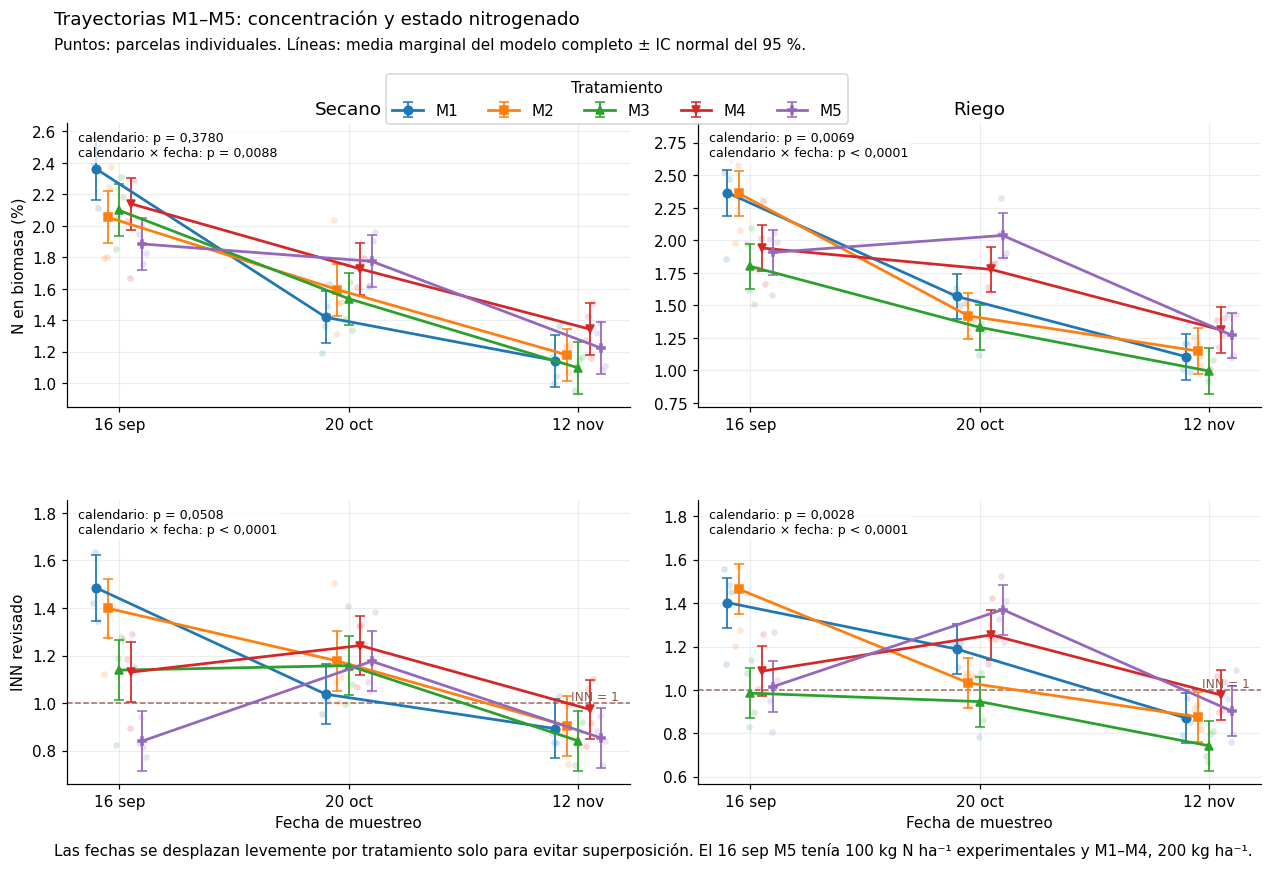

In [24]:
def mixed_emmeans(result: MixedTrajectoryResult) -> pd.DataFrame:
    fit = result.full_fit
    fixed_names = list(fit.fe_params.index)
    covariance = np.asarray(
        fit.cov_params().loc[fixed_names, fixed_names].to_numpy(), dtype=float
    )
    beta = np.asarray(fit.fe_params.to_numpy(), dtype=float)
    design_info = fit.model.data.design_info
    date_levels = [DATE_LABELS[date] for date in DATES]

    rows: list[dict[str, object]] = []
    for date_label in date_levels:
        for treatment in result.treatments:
            new = pd.DataFrame(
                {
                    "date_label": [date_label] * len(BLOCKS),
                    "treatment": [treatment] * len(BLOCKS),
                    "block": BLOCKS,
                }
            )
            new["date_label"] = categorical(new["date_label"], date_levels)
            new["treatment"] = categorical(new["treatment"], result.treatments)
            new["block"] = categorical(new["block"], BLOCKS)
            design = np.asarray(
                patsy_api.build_design_matrices([design_info], new)[0],
                dtype=float,
            )
            xbar = design.mean(axis=0)
            estimate_z = float(xbar @ beta)
            se_z = float(np.sqrt(xbar @ covariance @ xbar))
            estimate = result.center + result.scale * estimate_z
            se = result.scale * se_z
            rows.append(
                {
                    "date_label": date_label,
                    "treatment": treatment,
                    "estimate": estimate,
                    "se": se,
                    "ci_low": estimate - 1.96 * se,
                    "ci_high": estimate + 1.96 * se,
                    "design_vector": xbar,
                }
            )
    return pd.DataFrame(rows)


def mixed_early_late_contrasts(
    result: MixedTrajectoryResult,
) -> pd.DataFrame:
    if not set(FERTILIZED).issubset(result.treatments):
        raise ValueError("El contraste requiere M1–M5")
    emmeans = mixed_emmeans(result)
    fit = result.full_fit
    fixed_names = list(fit.fe_params.index)
    covariance = np.asarray(
        fit.cov_params().loc[fixed_names, fixed_names].to_numpy(), dtype=float
    )
    beta = np.asarray(fit.fe_params.to_numpy(), dtype=float)
    rows: list[dict[str, object]] = []
    for date_label in [DATE_LABELS[date] for date in DATES]:
        date_rows = emmeans.loc[emmeans["date_label"].eq(date_label)].set_index(
            "treatment"
        )
        early_vector = np.mean(
            np.vstack(
                [
                    np.asarray(cast(Any, date_rows.at["M1", "design_vector"])),
                    np.asarray(cast(Any, date_rows.at["M2", "design_vector"])),
                ]
            ),
            axis=0,
        )
        late_vector = np.mean(
            np.vstack(
                [
                    np.asarray(cast(Any, date_rows.at["M4", "design_vector"])),
                    np.asarray(cast(Any, date_rows.at["M5", "design_vector"])),
                ]
            ),
            axis=0,
        )
        contrast = early_vector - late_vector
        difference_z = float(contrast @ beta)
        se_z = float(np.sqrt(contrast @ covariance @ contrast))
        difference = result.scale * difference_z
        se = result.scale * se_z
        rows.append(
            {
                "date_label": date_label,
                "early_minus_late": difference,
                "se": se,
                "ci_low": difference - 1.96 * se,
                "ci_high": difference + 1.96 * se,
                "z": difference / se,
                "p_normal": 2.0 * stats.norm.sf(abs(difference / se)),
            }
        )
    return pd.DataFrame(rows)


def format_plot_p(value: float) -> str:
    if value < 0.0001:
        return "< 0,0001"
    return f"= {value:.4f}".replace(".", ",")


def plot_mixed_treatment(
    ax: Any,
    *,
    result: MixedTrajectoryResult,
    emmeans: pd.DataFrame,
    outcome: str,
    treatment: str,
    date_positions: dict[str, float],
    treatment_offsets: dict[str, float],
    block_offsets: dict[str, float],
) -> None:
    observed = result.frame.loc[
        result.frame["treatment"].astype(str).eq(treatment)
    ].copy()
    observed_x = np.asarray(
        [
            date_positions[str(date_label)]
            + treatment_offsets[treatment]
            + block_offsets[str(block)]
            for date_label, block in zip(
                observed["date_label"], observed["block"], strict=True
            )
        ]
    )
    ax.scatter(
        observed_x,
        observed[outcome],
        color=TREATMENT_COLORS[treatment],
        alpha=0.18,
        s=19,
        linewidths=0,
        zorder=1,
    )
    estimates = emmeans.loc[emmeans["treatment"].eq(treatment)].copy()
    estimate_x = np.asarray(
        [
            date_positions[str(date_label)] + treatment_offsets[treatment]
            for date_label in estimates["date_label"]
        ]
    )
    ax.errorbar(
        estimate_x,
        estimates["estimate"],
        yerr=[
            estimates["estimate"] - estimates["ci_low"],
            estimates["ci_high"] - estimates["estimate"],
        ],
        color=TREATMENT_COLORS[treatment],
        marker=TREATMENT_MARKERS[treatment],
        linewidth=1.8,
        markersize=5.6,
        capsize=3,
        elinewidth=1.15,
        label=treatment,
        zorder=3,
    )


def configure_mixed_outcome_axis(
    ax: Any,
    *,
    result: MixedTrajectoryResult,
    outcome: str,
    sector: str,
    row_index: int,
    column_index: int,
    outcome_count: int,
    date_positions: dict[str, float],
) -> None:
    if outcome == "nni_revised":
        ax.axhline(
            1.0,
            color=PLOT_PALETTE[5],
            linestyle="--",
            linewidth=1,
            alpha=0.85,
        )
        ax.text(
            0.98,
            1.0,
            "INN = 1",
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="bottom",
            fontsize=8,
            color=PLOT_PALETTE[5],
        )
    p_average = float(cast(Any, result.summary["p_average_treatment"]))
    p_interaction = float(cast(Any, result.summary["p_treatment_x_date"]))
    ax.text(
        0.02,
        0.97,
        (
            f"calendario: p {format_plot_p(p_average)}\n"
            f"calendario × fecha: p {format_plot_p(p_interaction)}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.3,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.78,
        },
    )
    ax.set_xticks(
        list(date_positions.values()),
        [DATE_LABELS[date] for date in DATES],
    )
    if row_index == outcome_count - 1:
        ax.set_xlabel("Fecha de muestreo")
    if column_index == 0:
        ax.set_ylabel(OUTCOME_LABELS[outcome])
    if row_index == 0:
        ax.set_title(sector)


def plot_mixed_outcome_panel(
    ax: Any,
    *,
    result: MixedTrajectoryResult,
    outcome: str,
    sector: str,
    row_index: int,
    column_index: int,
    outcome_count: int,
    date_positions: dict[str, float],
    treatment_offsets: dict[str, float],
    block_offsets: dict[str, float],
) -> None:
    emmeans = mixed_emmeans(result)
    for treatment in FERTILIZED:
        plot_mixed_treatment(
            ax,
            result=result,
            emmeans=emmeans,
            outcome=outcome,
            treatment=treatment,
            date_positions=date_positions,
            treatment_offsets=treatment_offsets,
            block_offsets=block_offsets,
        )
    configure_mixed_outcome_axis(
        ax,
        result=result,
        outcome=outcome,
        sector=sector,
        row_index=row_index,
        column_index=column_index,
        outcome_count=outcome_count,
        date_positions=date_positions,
    )


def plot_mixed_outcome_grid(
    outcomes: Sequence[str],
    *,
    title: str,
    filename_stem: str,
) -> None:
    date_levels = [DATE_LABELS[date] for date in DATES]
    date_positions = {
        date_label: float(index) for index, date_label in enumerate(date_levels)
    }
    treatment_offsets = dict(
        zip(FERTILIZED, np.linspace(-0.10, 0.10, len(FERTILIZED)), strict=True)
    )
    block_offsets = dict(
        zip(BLOCKS, np.linspace(-0.016, 0.016, len(BLOCKS)), strict=True)
    )
    fig, axes = mpl.subplots(
        len(outcomes),
        len(SECTORS),
        figsize=(12.2, 7.9),
        squeeze=False,
    )
    axes_array = np.asarray(axes)
    for row_index, outcome in enumerate(outcomes):
        for column_index, sector in enumerate(SECTORS):
            result = mixed_models[(outcome, sector, "M1–M5")]
            plot_mixed_outcome_panel(
                axes_array[row_index, column_index],
                result=result,
                outcome=outcome,
                sector=sector,
                row_index=row_index,
                column_index=column_index,
                outcome_count=len(outcomes),
                date_positions=date_positions,
                treatment_offsets=treatment_offsets,
                block_offsets=block_offsets,
            )

    handles, labels = axes_array[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Tratamiento",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.925),
        ncol=5,
    )
    fig.suptitle(title, x=0.08, y=0.99, ha="left")
    fig.text(
        0.08,
        0.945,
        (
            "Puntos: parcelas individuales. Líneas: media marginal del modelo completo "
            "± IC normal del 95 %."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.text(
        0.08,
        0.018,
        (
            "Las fechas se desplazan levemente por tratamiento solo para evitar superposición. "
            "El 16 sep M5 tenía 100 kg N ha⁻¹ experimentales y M1–M4, 200 kg ha⁻¹."
        ),
        color=mpl.rcParams["axes.labelcolor"],
    )
    fig.subplots_adjust(
        left=0.09,
        right=0.98,
        bottom=0.10,
        top=0.86,
        hspace=0.33,
        wspace=0.12,
    )
    save_figure(fig, filename_stem)
    mpl.show()
    mpl.close(fig)


contrast_rows: list[pd.DataFrame] = []
for outcome in LONGITUDINAL_OUTCOMES:
    for sector in SECTORS:
        result = mixed_models[(outcome, sector, "M1–M5")]
        contrasts = mixed_early_late_contrasts(result)
        contrasts.insert(0, "sector", sector)
        contrasts.insert(0, "outcome", OUTCOME_LABELS[outcome])
        contrast_rows.append(contrasts)

early_late_contrasts = pd.concat(contrast_rows, ignore_index=True)
display_output(early_late_contrasts.round(4))

plot_mixed_outcome_grid(
    ["biomass_kg_ha_used", "q_kg_n_ha"],
    title="Trayectorias M1–M5: crecimiento y N acumulado",
    filename_stem="figura_04_trayectorias_crecimiento_y_n_acumulado",
)
plot_mixed_outcome_grid(
    ["n_pct", "nni_revised"],
    title="Trayectorias M1–M5: concentración y estado nitrogenado",
    filename_stem="figura_05_trayectorias_estado_nitrogenado",
)

### 10.2 Sensibilidad de septiembre excluyendo M5

El 16 de septiembre M5 aún no había recibido la segunda aplicación. La comparación M1–M5 describe correctamente los calendarios completos, pero en esa fecha también incluye una diferencia transitoria de dosis acumulada. Como sensibilidad, se muestra M1–M4, donde todos habían completado los 200 kg N ha⁻¹.

In [25]:
sep_equal_dose_rows: list[dict[str, object]] = []
for outcome in LONGITUDINAL_OUTCOMES:
    for sector in SECTORS:
        frame = data.longitudinal.loc[
            data.longitudinal["date"].astype("datetime64[ns]").eq(DATES[0])
            & data.longitudinal["sector"].astype(str).eq(sector)
        ]
        result = fit_rcbd(
            frame,
            outcome=outcome,
            treatments=["M1", "M2", "M3", "M4"],
        )
        sep_equal_dose_rows.append(
            {
                "outcome": OUTCOME_LABELS[outcome],
                "sector": sector,
                "p_M1_M4": result.anova.loc["C(treatment)", "PR(>F)"],
                "cv_pct": result.cv_pct,
            }
        )
display_output(pd.DataFrame(sep_equal_dose_rows).round(4))

,outcome,sector,p_M1_M4,cv_pct
0,Biomasa aérea (kg MS ha⁻¹),Secano,0.0256,26.1114
1,Biomasa aérea (kg MS ha⁻¹),Riego,0.0172,10.6970
2,N en biomasa (%),Secano,0.4096,11.9926
3,N en biomasa (%),Riego,0.1192,17.1190
4,N acumulado (kg N ha⁻¹),Secano,0.0749,31.2769
5,N acumulado (kg N ha⁻¹),Riego,0.0097,19.8783
6,INN revisado,Secano,0.1185,16.1967
7,INN revisado,Riego,0.0278,17.2140


## 11. Selección sugerida de figuras para la tesis

No todas las figuras del cuaderno deberían pasar al cuerpo principal. La tabla siguiente separa las figuras que sostienen el argumento científico de las que funcionan mejor como respaldo técnico. El futuro anexo probabilístico probablemente sustituya o complemente el forest plot clásico de contrastes de rendimiento.

In [26]:
figure_manifest = pd.DataFrame(
    [
        {
            "archivo": "figura_01_cronograma_y_n_acumulado",
            "ubicación sugerida": "Métodos — cuerpo principal",
            "función": (
                "Define los calendarios, el cierre del pastoreo, las aplicaciones "
                "comunes y la dosis acumulada a cada muestreo."
            ),
            "prioridad": "Esencial",
        },
        {
            "archivo": "figura_02_aportes_mensuales_de_agua",
            "ubicación sugerida": "Sitio y manejo — cuerpo principal",
            "función": (
                "Muestra la distribución temporal de precipitación y riego sin "
                "confundir aportes brutos con agua disponible o consumida."
            ),
            "prioridad": "Alta",
        },
        {
            "archivo": "figura_03_rendimiento_dos_preguntas",
            "ubicación sugerida": "Resultados — cuerpo principal",
            "función": (
                "Separa la respuesta a N adicional de la comparación M1–M5 y "
                "muestra datos crudos, magnitud e incertidumbre."
            ),
            "prioridad": "Esencial",
        },
        {
            "archivo": "figura_04_trayectorias_crecimiento_y_n_acumulado",
            "ubicación sugerida": "Resultados — cuerpo principal",
            "función": (
                "Resume biomasa y N acumulado con datos individuales, medias "
                "longitudinales e interacción calendario × fecha."
            ),
            "prioridad": "Esencial",
        },
        {
            "archivo": "figura_05_trayectorias_estado_nitrogenado",
            "ubicación sugerida": "Resultados — cuerpo principal",
            "función": (
                "Resume concentración de N e INN; la referencia INN = 1 facilita "
                "la lectura agronómica."
            ),
            "prioridad": "Esencial",
        },
        {
            "archivo": "figura_06_componentes_del_rendimiento",
            "ubicación sugerida": "Resultados — cuerpo principal o síntesis",
            "función": (
                "Muestra los componentes con observaciones e intervalos sin usar la "
                "relación algebraica como prueba de compensación fisiológica."
            ),
            "prioridad": "Alta",
        },
        {
            "archivo": "anexo_contrastes_rendimiento",
            "ubicación sugerida": "Anexo o discusión de incertidumbre",
            "función": (
                "Cuantifica la respuesta frente a M0 y cuánto desacuerdo entre "
                "calendarios sigue siendo compatible con la inferencia clásica."
            ),
            "prioridad": "Alta hasta disponer del anexo probabilístico",
        },
        {
            "archivo": "anexo_trayectorias_observadas_*",
            "ubicación sugerida": "Anexo",
            "función": (
                "Conserva la comparación descriptiva M0–M5 sin confundirla con "
                "la pregunta longitudinal principal M1–M5."
            ),
            "prioridad": "Complementaria",
        },
    ]
)
display_output(figure_manifest)

,archivo,ubicación sugerida,función,prioridad
0,figura_01_cronograma_y_n_acumulado,Métodos — cuerpo principal,"Define los calendarios, el cierre del pastoreo...",Esencial
1,figura_02_aportes_mensuales_de_agua,Sitio y manejo — cuerpo principal,Muestra la distribución temporal de precipitac...,Alta
2,figura_03_rendimiento_dos_preguntas,Resultados — cuerpo principal,Separa la respuesta a N adicional de la compar...,Esencial
3,figura_04_trayectorias_crecimiento_y_n_acumulado,Resultados — cuerpo principal,Resume biomasa y N acumulado con datos individ...,Esencial
4,figura_05_trayectorias_estado_nitrogenado,Resultados — cuerpo principal,Resume concentración de N e INN; la referencia...,Esencial
5,figura_06_componentes_del_rendimiento,Resultados — cuerpo principal o síntesis,Muestra los componentes con observaciones e in...,Alta
6,anexo_contrastes_rendimiento,Anexo o discusión de incertidumbre,Cuantifica la respuesta frente a M0 y cuánto d...,Alta hasta disponer del anexo probabilístico
7,anexo_trayectorias_observadas_*,Anexo,Conserva la comparación descriptiva M0–M5 sin ...,Complementaria


## 12. Síntesis automática de resultados

Esta sección resume resultados ejecutados, no valores copiados manualmente.

In [27]:
def format_p(value: float) -> str:
    if value < 0.0001:
        return "< 0.0001"
    return f"{value:.4f}"


summary_lines: list[str] = []
for sector in SECTORS:
    primary = cast(
        Any,
        final_rcbd.loc[
            final_rcbd["outcome"].eq("clean_yield_kg_ha")
            & final_rcbd["sector"].eq(sector)
            & final_rcbd["comparison"].eq("M1–M5")
        ].iloc[0],
    )
    complementary = cast(
        Any,
        final_rcbd.loc[
            final_rcbd["outcome"].eq("clean_yield_kg_ha")
            & final_rcbd["sector"].eq(sector)
            & final_rcbd["comparison"].eq("M0–M5")
        ].iloc[0],
    )
    summary_lines.append(
        f"- **{sector}:** rendimiento M1–M5 p = {format_p(primary.p_treatment)}; "
        f"M0–M5 p = {format_p(complementary.p_treatment)}; "
        f"CV M1–M5 = {primary.cv_pct:.1f} % y CV M0–M5 = {complementary.cv_pct:.1f} % "
        f"(este último es el publicado en la tesis)."
    )

summary_lines.append(
    "\n**Pruebas longitudinales M1–M5 (interacción tratamiento × fecha):**"
)
for raw_row in mixed_summary.loc[mixed_summary["comparison"].eq("M1–M5")].itertuples(
    index=False
):
    row = cast(Any, raw_row)
    summary_lines.append(
        f"- {row.label}, {row.sector}: p = {format_p(row.p_treatment_x_date)}"
        + ("; varianza de parcela en el límite." if row.random_effect_boundary else ".")
    )

summary_lines.append(
    "\n**Lectura recomendada:** los ANOVA por fecha reproducen la tesis; el modelo longitudinal "
    "evalúa directamente si las trayectorias cambian con el calendario. La ausencia de una diferencia "
    "de rendimiento entre M1–M5 no debe traducirse en equivalencia exacta, y las diferencias entre "
    "sectores siguen siendo descriptivas."
)
display_output(Markdown("\n".join(summary_lines)))

- **Secano:** rendimiento M1–M5 p = 0.4287; M0–M5 p = < 0.0001; CV M1–M5 = 10.2 % y CV M0–M5 = 12.1 % (este último es el publicado en la tesis).
- **Riego:** rendimiento M1–M5 p = 0.1759; M0–M5 p = < 0.0001; CV M1–M5 = 12.9 % y CV M0–M5 = 13.5 % (este último es el publicado en la tesis).

**Pruebas longitudinales M1–M5 (interacción tratamiento × fecha):**
- Biomasa aérea (kg MS ha⁻¹), Secano: p = 0.0746; varianza de parcela en el límite.
- Biomasa aérea (kg MS ha⁻¹), Riego: p = 0.7863; varianza de parcela en el límite.
- N en biomasa (%), Secano: p = 0.0088; varianza de parcela en el límite.
- N en biomasa (%), Riego: p = < 0.0001; varianza de parcela en el límite.
- N acumulado (kg N ha⁻¹), Secano: p = 0.0004; varianza de parcela en el límite.
- N acumulado (kg N ha⁻¹), Riego: p = 0.0004; varianza de parcela en el límite.
- INN revisado, Secano: p = < 0.0001; varianza de parcela en el límite.
- INN revisado, Riego: p = < 0.0001; varianza de parcela en el límite.

**Lectura recomendada:** los ANOVA por fecha reproducen la tesis; el modelo longitudinal evalúa directamente si las trayectorias cambian con el calendario. La ausencia de una diferencia de rendimiento entre M1–M5 no debe traducirse en equivalencia exacta, y las diferencias entre sectores siguen siendo descriptivas.

## 13. Exportación de tablas y figuras

Se exportan resultados derivados, no una copia alterada del libro original.

In [ ]:
if EXPORT_RESULTS:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    longitudinal_rcbd.to_csv(RESULTS_DIR / "anova_por_fecha_y_sector.csv", index=False)
    final_rcbd.to_csv(RESULTS_DIR / "anova_variables_finales.csv", index=False)
    joint_results.to_csv(RESULTS_DIR / "anova_conjunto_entre_sectores.csv", index=False)
    diagnostics.to_csv(RESULTS_DIR / "diagnosticos_modelos_clasicos.csv", index=False)
    raw_correlations.to_csv(RESULTS_DIR / "correlaciones_tesis.csv", index=False)
    correlation_audit.to_csv(
        RESULTS_DIR / "correlaciones_extension_auditoria.csv", index=False
    )
    mixed_summary.to_csv(RESULTS_DIR / "modelos_longitudinales_mixtos.csv", index=False)
    early_late_contrasts.to_csv(
        RESULTS_DIR / "contrastes_temprano_menos_tardio.csv", index=False
    )
    flagged_dm.to_csv(
        RESULTS_DIR / "registros_materia_seca_a_verificar.csv", index=False
    )
    figure_manifest.to_csv(RESULTS_DIR / "seleccion_figuras_tesis.csv", index=False)
    water_inputs.to_csv(RESULTS_DIR / "aportes_mensuales_de_agua.csv", index=False)
    yield_contrasts.to_csv(
        RESULTS_DIR / "contrastes_rendimiento_clasicos.csv", index=False
    )
    print("Tablas exportadas en:", RESULTS_DIR.resolve())
    for path in sorted(RESULTS_DIR.glob("*.csv")):
        print(" -", path.name)

if EXPORT_FIGURES:
    print("Figuras exportadas en:", FIGURES_DIR.resolve())
    for path in sorted(FIGURES_DIR.glob("*")):
        if path.suffix.lower() in {".png", ".pdf"}:
            print(" -", path.name)

## 14. Alcance y límites

- La parcela es la unidad experimental del momento de aplicación dentro de cada sector.
- Secano y riego suplementario ocupan un único sector cada uno; el cuaderno no estima un efecto causal general del riego.
- Las mediciones de junio son descriptivas y no permiten ajuste basal por parcela.
- El dato faltante de N no se imputa en el análisis principal.
- Los registros de materia seca 150 y 152 requieren verificación primaria; la política por defecto conserva los datos usados por la tesis.
- El número estimado de semillas por panoja, el índice de cosecha, la merma, la eficiencia agronómica y la productividad aparente del agua comparten componentes algebraicos con otras variables y no generan evidencia independiente por el mero hecho de ser analizados como columnas separadas.
- Los valores de p del modelo mixto se basan en aproximaciones asintóticas de razón de verosimilitudes. Con 20 o 24 parcelas por sector, deben acompañarse con magnitudes, intervalos, gráficos y sensibilidad.